# 平推球程式

**用途**：拿平推球資料訓練/評估模型，用 CNN 架構做 Transfer Learning（跟挑球程式類似，但只做了 CNN 這條線，沒有 LSTM／CNN+LSTM 段落）

**輸入**：
- `./推cut.json`（平推球的分數+檔名對照表）
- `models/cnn_base_model1~5.keras`（⚠️ 來自「高遠球程式(舊).ipynb」，缺這些會跑不動）

**輸出**：無存檔，訓練結果只在 notebook 內顯示/畫圖

**狀態**：✅ 使用中（比 `挑球程式.ipynb` 少做 LSTM 跟 CNN+LSTM 兩段，看起來像是還沒做完/或故意只測 CNN）

**更新日期**：2026-08-15

In [274]:
import os
import json
import pandas as pd
import numpy as np
import re
import math

# 定義預期的評分欄位名稱
SCORE_COLUMNS = [
    "揮拍軌跡正確度",
    "揮拍速度流暢度",
    "手腕轉動時機正確度",
    "擊球時機正確度",
    "擊球位置正確度"
]

class Data:
    acc_x: np.ndarray
    acc_y: np.ndarray
    acc_z: np.ndarray
    ang_acc_x: np.ndarray
    ang_acc_y: np.ndarray
    ang_acc_z: np.ndarray
    def __init__(self):
        self.acc_x = []
        self.acc_y = []
        self.acc_z = []
        self.ang_acc_x = []
        self.ang_acc_y = []
        self.ang_acc_z = []

# 初始化
json_list = []
data = Data()

# 讀取分段 CSV 的資料夾
folder_path = "C:/Users/gordo/AI-badminton/推cut"
output_json = "C:/Users/gordo/AI-badminton/推cut.json"
score_file_path = "羽球評分(全).xlsx" # 評分 Excel 檔案路徑


# 讀取評分 Excel 檔案 【已修改：指定 sheet_name='挑球'】
try:
    score_df = pd.read_excel(score_file_path, sheet_name='平推球')
    # 確保用於匹配的檔名欄位是字串型別，並移除檔案名稱尾碼
    # 注意：這裡的 '檔名' 欄位名稱是假設 Excel 工作表中用於匹配的欄位名
    if '檔名' in score_df.columns:
        score_df['檔名'] = score_df['檔名'].astype(str).str.split('.').str[0]
    elif '名稱' in score_df.columns:
         # 根據您上傳的檔案片段，實際欄位名稱可能是 '名稱'
        score_df['檔名'] = score_df['名稱'].astype(str).str.split('.').str[0]
    else:
        print("錯誤：評分檔案中找不到 '檔名' 或 '名稱' 欄位作為匹配鍵。")
        exit()

except Exception as e:
    print(f"錯誤：無法讀取評分檔案 '{score_file_path}' 的工作表 '挑球' 或處理其欄位：{e}")
    # 如果讀取失敗，程式將無法繼續，因為無法取得分數
    exit()


# 假設 json_list 已經在外部定義
# 假設 data 是一個物件，包含 acc_x, ang_acc_x 等屬性
# 假設 scores 是一個字典，包含五個評分面向的原始分數 (1-5 或 1-3)

def create_json_file_with_conversion(file_name, scores, data, json_list):
    """
    根據當前 CSV 數據和對應的評分，建立 JSON 物件並加入列表。
    **評分欄位將被轉換為 0, 1, 2 三個類別 (從原始 1-5 分壓縮而來)。**
    """
    
    # --- 定義轉換函式 ---
    def convert_score_to_category(score):
        """將原始分數 x (假設 1-5) 轉換為 0, 1, 2 類別的字串。"""
        # 轉換公式: floor((x - 1) / 2)
        # 1, 2 -> 0 (低分)
        # 3, 4 -> 1 (中分)
        # 5 -> 2 (高分)
        
        # 確保分數是數值類型
        score = int(score) 
        
        # 執行轉換並轉為字串
        return str(math.floor((score - 1) / 2))
    # ----------------------
    
    # 執行轉換並建立 JSON 物件
    json_list.append({
        "檔名": file_name, 
        
        # **套用轉換函式來生成 0, 1, 2 的字串**
        "揮拍軌跡正確度": convert_score_to_category(scores["揮拍軌跡正確度"]),
        "揮拍速度流暢度": convert_score_to_category(scores["揮拍速度流暢度"]),
        "手腕轉動時機正確度": convert_score_to_category(scores["手腕轉動時機正確度"]),
        "擊球時機正確度": convert_score_to_category(scores["擊球時機正確度"]),
        "擊球位置正確度": convert_score_to_category(scores["擊球位置正確度"]),
        
        # 以下數據讀取不變
        "x軸加速度": list(np.around(data.acc_x, 3)),
        "y軸加速度": list(np.around(data.acc_y, 3)),
        "z軸加速度": list(np.around(data.acc_z, 3)),
        "x軸角加速度": list(np.around(data.ang_acc_x, 3)),
        "y軸角加速度": list(np.around(data.ang_acc_y, 3)),
        "z軸角加速度": list(np.around(data.ang_acc_z, 3)),
    })

# 遍歷分段 CSV
def natural_sort_key(s):
    return [int(text) if text.isdigit() else text.lower()
            for text in re.split('([0-9]+)', s)]

csv_files = sorted(
    [f for f in os.listdir(folder_path) if f.endswith(".csv")],
    key=natural_sort_key
)

for file_name in csv_files:
    file_path = os.path.join(folder_path, file_name)
    
    # 原始不含副檔名的檔名，例如 "shot_A_1"
    full_stem = file_name.split('.')[0] 
    
    # 1. 處理檔名：移除底線及後面的數字
    if '_' in full_stem:
        # 取得不含流水號的名稱 (例如: "shot_A")
        match_stem = full_stem.rsplit('_', 1)[0]
    else:
        match_stem = full_stem
    
    # 讀取 CSV 資料並填充 data 物件
    df = pd.read_csv(file_path, header=None)
    df = df.drop(columns=[4])
    df.columns = ['時間','x軸加速度','y軸加速度','z軸加速度','x軸角加速度','y軸角加速度','z軸角加速度']
    
    data.acc_x = np.array(df['x軸加速度'].tolist())
    data.acc_y = np.array(df['y軸加速度'].tolist())
    data.acc_z = np.array(df['z軸加速度'].tolist())
    data.ang_acc_x = np.array(df['x軸角加速度'].tolist())
    data.ang_acc_y = np.array(df['y軸角加速度'].tolist())
    data.ang_acc_z = np.array(df['z軸角加速度'].tolist())
    
    # 查找 Excel 表中 '檔名' 欄位與處理後的名稱 (clean_match_stem) 匹配的行
    score_row = score_df[score_df['檔名'] == match_stem]
    
    # 重新加入檢查：避免 IndexError
    if score_row.empty:
        print(f"警告: 評分表找不到名稱 '{match_stem}' (來自原始檔 '{full_stem}') 的分數，跳過此檔案的 JSON 寫入。")
        continue # 跳過本次迴圈

    # 提取分數並轉換為字典
    current_scores = score_row[SCORE_COLUMNS].iloc[0].to_dict()

    # 呼叫建立 JSON 函式，傳入原始檔名 (full_stem) 作為 JSON 輸出中的「檔名」
    create_json_file_with_conversion(full_stem, current_scores, data, json_list)


# 輸出 JSON 檔
with open(output_json, 'w', encoding='utf-8') as file:
    json.dump(json_list, file, ensure_ascii=False, indent=4)

print("JSON 檔生成成功:", output_json)

警告: 評分表找不到名稱 '110129推' (來自原始檔 '110129推_2') 的分數，跳過此檔案的 JSON 寫入。
警告: 評分表找不到名稱 '110129推' (來自原始檔 '110129推_3') 的分數，跳過此檔案的 JSON 寫入。
警告: 評分表找不到名稱 '110129推' (來自原始檔 '110129推_4') 的分數，跳過此檔案的 JSON 寫入。
警告: 評分表找不到名稱 '110129推' (來自原始檔 '110129推_5') 的分數，跳過此檔案的 JSON 寫入。
警告: 評分表找不到名稱 '110129推' (來自原始檔 '110129推_6') 的分數，跳過此檔案的 JSON 寫入。
警告: 評分表找不到名稱 '110129推' (來自原始檔 '110129推_7') 的分數，跳過此檔案的 JSON 寫入。
警告: 評分表找不到名稱 '110129推' (來自原始檔 '110129推_8') 的分數，跳過此檔案的 JSON 寫入。
警告: 評分表找不到名稱 '110129推' (來自原始檔 '110129推_9') 的分數，跳過此檔案的 JSON 寫入。
警告: 評分表找不到名稱 '110129推' (來自原始檔 '110129推_10') 的分數，跳過此檔案的 JSON 寫入。
警告: 評分表找不到名稱 '110129推' (來自原始檔 '110129推_11') 的分數，跳過此檔案的 JSON 寫入。
警告: 評分表找不到名稱 '110129推' (來自原始檔 '110129推_12') 的分數，跳過此檔案的 JSON 寫入。
警告: 評分表找不到名稱 '110129推' (來自原始檔 '110129推_13') 的分數，跳過此檔案的 JSON 寫入。
警告: 評分表找不到名稱 '110129推' (來自原始檔 '110129推_14') 的分數，跳過此檔案的 JSON 寫入。
警告: 評分表找不到名稱 '110129推' (來自原始檔 '110129推_15') 的分數，跳過此檔案的 JSON 寫入。
警告: 評分表找不到名稱 '110129推' (來自原始檔 '110129推_16') 的分數，跳過此檔案的 JSON 寫入。
警告: 評分表找不到名稱 '110129推' (來自原始檔 '110129推_17') 的分數，

In [275]:
import json
with open('./推cut.json', 'r', encoding='utf-8') as file:
    data_drive = json.load(file)
    
df_drive = pd.DataFrame(data_drive)
print(df_drive)

              檔名 揮拍軌跡正確度 揮拍速度流暢度 手腕轉動時機正確度 擊球時機正確度 擊球位置正確度  \
0       10281推_1       2       1         2       2       2   
1       10281推_2       2       1         2       2       2   
2       10281推_3       2       1         2       2       2   
3       10281推_4       2       1         2       2       2   
4       10281推_5       2       1         2       2       2   
...          ...     ...     ...       ...     ...     ...   
1704  110142推_30       2       2         2       2       2   
1705  110142推_31       2       2         2       2       2   
1706  110142推_32       2       2         2       2       2   
1707  110142推_33       2       2         2       2       2   
1708  110142推_34       2       2         2       2       2   

                                                  x軸加速度  \
0     [10.588, 10.136, 9.712, 9.596, 9.164, 8.264, 7...   
1     [8.472, 7.51, 7.406, 8.054, 8.362, 8.448, 7.82...   
2     [5.904, 6.488, 7.09, 7.786, 8.42, 9.064, 9.606...   
3     [7.704, 7.824

In [276]:
y1 = df_drive['揮拍軌跡正確度'].values.astype(int)
y2 = df_drive['揮拍速度流暢度'].values.astype(int)
y3 = df_drive['手腕轉動時機正確度'].values.astype(int)
y4 = df_drive['擊球時機正確度'].values.astype(int)
y5 = df_drive['擊球位置正確度'].values.astype(int)
Y=[y1,y2,y3,y4,y5]
drive_high_file = []
drive_mid_file = []
drive_low_file = []

for i in range(len(data_drive)):
    avg = (y1[i] + y2[i] + y3[i] + y4[i] + y5[i])/5
    if avg == 2:
        drive_high_file.append(df_drive['檔名'][i].split('_')[0])
    elif avg < 2 and avg > 0.7:
        drive_mid_file.append(df_drive['檔名'][i].split('_')[0])
    else:
        drive_low_file.append(df_drive['檔名'][i].split('_')[0])

drive_high_file = list(set(drive_high_file))
drive_mid_file = list(set(drive_mid_file))
drive_low_file = list(set(drive_low_file))
print(drive_high_file)
print(drive_mid_file)
print(drive_low_file)

['10285推', '10287推', '11201推', '10283推', '110127推', '110140推', '11019推', '11011推', '10288推', '110116推', '110119推', '10303推', '110142推', '110137推', '110125推', '11018推', '10284推補', '11041推', '110112推', '110124推', '110134推']
['11131推', '11132推', '110110推', '110120推', '110131推', '11013推', '11015推', '110136推', '10305推', '110111推', '10282推', '10301推', '110121推', '110122推', '110132推', '110114推', '11202推', '10304推', '110133推', '110115推', '11014推', '110141推', '110138推', '110135推', '110118推', '10302推', '10281推', '110113推', '110123推']
['11017推', '110139推', '11016推', '11012推', '10286推', '110117推', '110126推', '110128推補']


In [277]:
from sklearn.model_selection import train_test_split

# 確保 drive_high_file, drive_mid_file, drive_low_file 已經定義並包含去重後的檔案名稱
FIXED_RANDOM_STATE = 41
# 初始化最終的訓練集和測試集檔案名稱列表
drive_train_file_list = []
drive_test_file_list = []

print("=== 抽球 (Drive) 檔案切分開始 ===")
print(f"原始高分檔案數: {len(drive_high_file)}")
print(f"原始中分檔案數: {len(drive_mid_file)}")
print(f"原始低分檔案數: {len(drive_low_file)}")
print("-" * 30)

# --- 1. 對高分檔案進行 80/20 切分 (隨機) ---
if drive_high_file:
    drive_high_train, drive_high_test = train_test_split(
        drive_high_file,
        test_size=0.4, # 20% 作為測試集
        shuffle=True    # 每次都打亂
    )
    # 使用 drive_high_train/drive_high_test 進行 extend
    drive_train_file_list.extend(drive_high_train)
    drive_test_file_list.extend(drive_high_test)
    print(f"高分組：訓練 {len(drive_high_train)} 個, 測試 {len(drive_high_test)} 個")
else:
    print("高分組檔案列表為空，未進行切分。")

# --- 2. 對中分檔案進行 80/20 切分 (隨機) ---
if drive_mid_file:
    drive_mid_train, drive_mid_test = train_test_split(
        drive_mid_file,
        test_size=0.4,
        shuffle=True,
        random_state=FIXED_RANDOM_STATE
    )
    drive_train_file_list.extend(drive_mid_train)
    drive_test_file_list.extend(drive_mid_test)
    print(f"中分組：訓練 {len(drive_mid_train)} 個, 測試 {len(drive_mid_test)} 個")
else:
    print("中分組檔案列表為空，未進行切分。")

# --- 3. 對低分檔案進行 80/20 切分 (隨機) ---
if drive_low_file:
    drive_low_train, drive_low_test = train_test_split(
        drive_low_file,
        test_size=0.4,
        shuffle=True,
        random_state=FIXED_RANDOM_STATE
    )
    drive_train_file_list.extend(drive_low_train)
    drive_test_file_list.extend(drive_low_test)
    print(f"低分組：訓練 {len(drive_low_train)} 個, 測試 {len(drive_low_test)} 個")
else:
    print("低分組檔案列表為空，未進行切分。")


# --- 統整最終的訓練集和測試集檔案名稱列表 ---

# 訓練集檔案名稱總列表
drive_final_train_files = drive_train_file_list

# 測試集檔案名稱總列表
drive_final_test_files = drive_test_file_list

# 驗證總數是否正確
drive_total_files_in_lists = len(drive_final_train_files) + len(drive_final_test_files)
drive_total_files_original = len(drive_high_file) + len(drive_mid_file) + len(drive_low_file)

print("-" * 30)
print("✅ 抽球檔案名稱統整完成！")
print(f"總訓練檔案數: {len(drive_final_train_files)}")
print(f"總測試檔案數: {len(drive_final_test_files)}")
print(f"總檔案數 (訓練 + 測試): {drive_total_files_in_lists}")
print("-" * 30)

# 顯示所有檔案名稱以供檢查
print("訓練集檔案名稱:", drive_final_train_files)
print("測試集檔案名稱:", drive_final_test_files)

=== 抽球 (Drive) 檔案切分開始 ===
原始高分檔案數: 21
原始中分檔案數: 29
原始低分檔案數: 8
------------------------------
高分組：訓練 12 個, 測試 9 個
中分組：訓練 17 個, 測試 12 個
低分組：訓練 4 個, 測試 4 個
------------------------------
✅ 抽球檔案名稱統整完成！
總訓練檔案數: 33
總測試檔案數: 25
總檔案數 (訓練 + 測試): 58
------------------------------
訓練集檔案名稱: ['110142推', '10285推', '11041推', '10288推', '10303推', '11201推', '110140推', '10283推', '110119推', '110116推', '11019推', '110124推', '110111推', '110118推', '110131推', '110123推', '11015推', '110133推', '110113推', '10281推', '110122推', '110141推', '110115推', '11132推', '11202推', '110110推', '110121推', '110120推', '11131推', '11016推', '10286推', '11012推', '11017推']
測試集檔案名稱: ['110137推', '110134推', '11018推', '110125推', '110127推', '10284推補', '10287推', '11011推', '110112推', '10301推', '110114推', '10282推', '110138推', '10302推', '11013推', '110135推', '11014推', '110136推', '110132推', '10305推', '10304推', '110126推', '110117推', '110139推', '110128推補']


In [278]:
import numpy as np
import pandas as pd # 確保已載入

df_train_drive = df_drive[df_drive['檔名'].apply(lambda x: x.split('_')[0]).isin(drive_final_train_files)].copy()
df_test_drive = df_drive[df_drive['檔名'].apply(lambda x: x.split('_')[0]).isin(drive_final_test_files)].copy()


In [279]:

print(df_train_drive.index.tolist()[-1])
print(df_test_drive.index.tolist()[-1])
df_train_drive = df_train_drive.reset_index(drop=True) 

# 此時，df_train 的索引就是 0, 1, 2, ..., 4677
# 假設 df 是您的原始完整 DataFrame
print("--- df_train_drive 處理完成 ---")
print(f"df_train_drive 的樣本總數 (rows): {len(df_train_drive)}")
print(f"df_train_drive 的新索引範圍為 0 到 {len(df_train_drive) - 1}。")
# 假設 overall_test_file 是 20% 檔案名稱列表

df_test_drive = df_test_drive.reset_index(drop=True) 

# 輸出檢查
print("--- df_test_drive 處理完成 ---")
print(f"df_test_drive 的樣本總數 (rows): {len(df_test_drive)}")
print(f"df_test_drive 的新索引範圍為 0 到 {len(df_test_drive) - 1}。")

1708
1612
--- df_train_drive 處理完成 ---
df_train_drive 的樣本總數 (rows): 964
df_train_drive 的新索引範圍為 0 到 963。
--- df_test_drive 處理完成 ---
df_test_drive 的樣本總數 (rows): 745
df_test_drive 的新索引範圍為 0 到 744。


In [280]:
display(df_train_drive)

,檔名,揮拍軌跡正確度,揮拍速度流暢度,手腕轉動時機正確度,擊球時機正確度,擊球位置正確度,x軸加速度,y軸加速度,z軸加速度,x軸角加速度,y軸角加速度,z軸角加速度
0,10281推_1,2,1,2,2,2,"[10.588, 10.136, 9.712, 9.596, 9.164, 8.264, 7...","[-10.288, -7.88, -5.32, -3.328, -2.088, -1.226...","[3.598, 4.568, 5.194, 5.114, 4.946, 4.594, 4.0...","[1.082, 0.626, 0.186, -0.102, -0.438, -0.74, -...","[0.468, 0.54, 0.562, 0.48, 0.278, 0.198, 0.15,...","[-0.146, -0.124, -0.048, -0.044, -0.12, -0.268..."
1,10281推_2,2,1,2,2,2,"[8.472, 7.51, 7.406, 8.054, 8.362, 8.448, 7.82...","[-11.514, -8.078, -4.608, -2.852, -2.42, -3.14...","[10.148, 12.628, 15.004, 16.128, 16.07, 15.754...","[5.914, 5.506, 5.224, 5.242, 5.502, 5.95, 5.93...","[1.79, 2.238, 2.614, 2.802, 2.804, 2.714, 2.75...","[3.666, 3.76, 3.944, 4.146, 4.372, 4.466, 4.34..."
2,10281推_3,2,1,2,2,2,"[5.904, 6.488, 7.09, 7.786, 8.42, 9.064, 9.606...","[-2.294, -3.778, -5.326, -6.17, -6.72, -7.544,...","[4.016, 4.388, 4.656, 5.042, 5.262, 5.188, 5.0...","[-0.136, 0.07, 0.246, 0.428, 0.552, 0.63, 0.68...","[-0.256, -0.19, -0.144, -0.04, 0.092, 0.188, 0...","[-0.158, -0.11, -0.008, 0.06, 0.104, 0.12, 0.0..."
3,10281推_4,2,1,2,2,2,"[7.704, 7.824, 8.034, 8.338, 8.566, 8.766, 9.1...","[-4.07, -4.004, -4.296, -4.228, -3.606, -3.06,...","[4.906, 4.692, 4.884, 5.102, 5.112, 5.146, 5.4...","[0.572, 0.452, 0.234, 0.002, -0.164, -0.258, -...","[-0.21, -0.28, -0.322, -0.296, -0.236, -0.188,...","[-0.164, -0.198, -0.262, -0.334, -0.352, -0.32..."
4,10281推_5,2,1,2,2,2,"[8.086, 7.666, 7.302, 7.08, 6.866, 6.656, 6.50...","[-5.282, -5.108, -5.032, -4.868, -4.584, -4.17...","[4.928, 4.968, 4.948, 4.786, 4.638, 4.49, 4.15...","[-0.076, -0.132, -0.18, -0.222, -0.242, -0.164...","[0.144, 0.106, 0.062, 0.008, -0.018, -0.016, -...","[0.132, 0.1, 0.056, -0.006, -0.07, -0.12, -0.1..."
...,...,...,...,...,...,...,...,...,...,...,...,...
959,110142推_30,2,2,2,2,2,"[-7.68, -7.71, -7.756, -7.526, -7.308, -7.32, ...","[-5.286, -5.522, -6.038, -6.458, -6.458, -6.16...","[2.566, 2.602, 2.926, 3.28, 3.784, 4.042, 3.99...","[0.086, 0.09, 0.108, 0.088, 0.02, 0.11, 0.498,...","[0.12, 0.142, 0.18, 0.198, 0.216, 0.246, 0.222...","[-0.322, -0.346, -0.424, -0.524, -0.592, -0.62..."
960,110142推_31,2,2,2,2,2,"[-5.698, -5.368, -4.952, -4.594, -4.382, -4.23...","[-6.474, -6.214, -6.1, -5.904, -5.692, -5.802,...","[4.978, 4.794, 4.488, 4.254, 4.234, 4.168, 4.6...","[1.186, 1.164, 1.242, 1.302, 1.442, 1.652, 1.6...","[-0.518, -0.458, -0.428, -0.392, -0.346, -0.29...","[-1.134, -1.092, -1.052, -1.042, -1.056, -1.05..."
961,110142推_32,2,2,2,2,2,"[-6.294, -6.36, -6.258, -6.068, -5.836, -5.616...","[-4.0, -3.774, -3.756, -3.772, -3.742, -3.732,...","[7.18, 7.264, 7.324, 7.364, 7.342, 7.292, 7.44...","[1.414, 1.292, 1.294, 1.48, 1.808, 2.046, 2.16...","[-0.716, -0.708, -0.666, -0.584, -0.514, -0.47...","[-1.432, -1.488, -1.51, -1.528, -1.554, -1.572..."
962,110142推_33,2,2,2,2,2,"[-6.69, -6.656, -6.544, -6.304, -6.296, -6.498...","[-5.522, -4.992, -4.572, -4.758, -5.278, -5.85...","[6.842, 6.938, 6.906, 7.058, 7.598, 7.318, 7.0...","[1.022, 0.926, 1.19, 1.608, 2.074, 2.46, 2.712...","[-0.68, -0.694, -0.738, -0.72, -0.654, -0.624,...","[-1.384, -1.522, -1.622, -1.648, -1.66, -1.664..."


In [281]:
display(df_test_drive)

,檔名,揮拍軌跡正確度,揮拍速度流暢度,手腕轉動時機正確度,擊球時機正確度,擊球位置正確度,x軸加速度,y軸加速度,z軸加速度,x軸角加速度,y軸角加速度,z軸角加速度
0,10282推_1,2,1,1,1,1,"[3.746, 3.566, 4.066, 3.754, 3.556, 3.736, 3.6...","[-7.772, -7.16, -7.574, -7.914, -7.968, -8.132...","[3.708, 2.832, 3.254, 4.496, 4.502, 4.15, 4.15...","[-0.312, -0.486, -0.49, -0.264, 0.018, 0.178, ...","[1.178, 1.208, 1.238, 1.136, 0.98, 0.91, 0.846...","[-0.89, -0.916, -0.87, -0.87, -0.906, -0.9, -0..."
1,10282推_2,2,1,1,1,1,"[1.454, 1.33, 1.82, 2.438, 2.796, 2.634, 2.06,...","[-8.294, -7.746, -7.072, -6.9, -7.674, -9.016,...","[4.444, 5.018, 5.53, 6.02, 6.15, 5.102, 3.93, ...","[0.648, 0.106, -0.612, -0.876, -0.736, -0.404,...","[-1.296, -1.34, -1.312, -1.406, -1.552, -1.65,...","[0.756, 1.028, 1.47, 1.718, 1.932, 2.254, 2.61..."
2,10282推_3,2,1,1,1,1,"[1.89, 1.132, 0.008, -1.076, -2.044, -2.286, -...","[-8.332, -8.67, -8.998, -9.53, -9.518, -9.202,...","[4.514, 4.678, 4.642, 5.116, 5.898, 6.492, 7.1...","[0.626, 0.492, 0.516, 0.738, 0.942, 0.98, 0.94...","[-0.874, -0.846, -0.942, -1.02, -1.022, -1.022...","[1.552, 1.922, 2.15, 2.304, 2.47, 2.634, 2.784..."
3,10282推_4,2,1,1,1,1,"[2.054, 1.802, 1.902, 1.812, 1.254, 0.992, 0.8...","[-7.324, -7.234, -7.372, -7.678, -7.646, -7.35...","[3.598, 3.33, 3.416, 3.736, 4.356, 5.06, 5.398...","[0.488, 0.28, -0.042, -0.296, -0.252, 0.028, 0...","[-0.556, -0.676, -0.776, -0.92, -1.21, -1.502,...","[0.34, 0.396, 0.466, 0.632, 0.814, 0.916, 1.04..."
4,10282推_5,2,1,1,1,1,"[0.536, 0.59, 0.658, 0.558, 0.394, 0.05, -0.08...","[-7.918, -7.876, -7.982, -8.344, -8.928, -9.30...","[6.052, 5.914, 5.584, 5.288, 4.622, 3.804, 3.7...","[0.548, 0.78, 0.756, 0.472, 0.464, 0.588, 0.85...","[-1.914, -2.128, -2.154, -2.124, -2.156, -2.18...","[1.676, 1.876, 2.18, 2.484, 2.664, 2.868, 3.01..."
...,...,...,...,...,...,...,...,...,...,...,...,...
740,110139推_28,1,0,1,0,1,"[4.262, 4.202, 4.094, 4.096, 3.984, 3.944, 3.9...","[-8.288, -8.226, -8.196, -8.332, -8.434, -8.28...","[3.54, 3.34, 3.316, 3.336, 3.236, 3.108, 3.064...","[0.462, 0.4, 0.274, 0.144, 0.068, 0.052, 0.06,...","[-0.152, -0.146, -0.122, -0.09, -0.062, -0.044...","[-0.116, -0.094, -0.076, -0.056, -0.022, 0.016..."
741,110139推_29,1,0,1,0,1,"[3.392, 3.492, 3.536, 3.554, 3.56, 3.536, 3.50...","[-9.592, -9.706, -9.862, -10.028, -9.856, -9.5...","[2.164, 2.06, 1.954, 1.942, 1.786, 1.702, 1.55...","[0.132, 0.0, -0.012, 0.104, 0.212, 0.238, 0.19...","[-0.5, -0.43, -0.38, -0.366, -0.338, -0.258, -...","[0.396, 0.506, 0.596, 0.698, 0.84, 0.964, 1.04..."
742,110139推_30,1,0,1,0,1,"[5.394, 5.608, 5.772, 6.034, 6.378, 6.668, 6.8...","[-9.024, -9.518, -9.416, -8.786, -8.358, -8.76...","[2.498, 2.872, 3.294, 3.602, 3.814, 3.486, 3.3...","[0.32, 0.274, 0.15, 0.106, 0.1, 0.078, 0.1, 0....","[0.374, 0.498, 0.656, 0.778, 0.906, 1.002, 1.0...","[1.968, 2.2, 2.402, 2.582, 2.782, 3.006, 3.204..."
743,110139推_31,1,0,1,0,1,"[5.958, 5.964, 5.822, 5.692, 5.802, 6.046, 6.2...","[-7.272, -7.44, -7.246, -6.996, -7.194, -7.78,...","[2.26, 2.132, 2.19, 2.154, 2.136, 2.128, 2.022...","[0.418, 0.354, 0.248, 0.184, 0.168, 0.17, 0.18...","[-0.248, -0.186, -0.128, -0.074, -0.018, 0.014...","[-0.704, -0.64, -0.57, -0.508, -0.436, -0.348,..."


In [282]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
import random

features = ['x軸加速度', 'y軸加速度', 'z軸加速度', 
            'x軸角加速度', 'y軸角加速度', 'z軸角加速度']

scalers = {}
X_train_list = []
X_test_list = []

# --- 1. Scaler 擬合與數據縮放 ---
for feature in features:
    
    # 創建新的 Scaler
    scaler = MinMaxScaler()

    # ------ 訓練資料 Fit & Transform ------
    # 將 df_train 中該特徵的所有時序數據攤平，以供 Scaler 擬合
    # .tolist() 將所有時序列表組合成一個列表，np.concatenate 攤平
    train_data = np.concatenate(df_train_drive[feature].tolist()).reshape(-1, 1)

    # Fit (僅在訓練數據上擬合)
    scaler.fit(train_data)
    scalers[feature] = scaler

    # Transform 後儲存
    train_scaled = scaler.transform(train_data)
    X_train_list.append(train_scaled)


    # ------ 測試資料 Transform ------
    test_data = np.concatenate(df_test_drive[feature].tolist()).reshape(-1, 1)

    # 僅 Transform (使用訓練好的 Scaler)
    test_scaled = scaler.transform(test_data)
    X_test_list.append(test_scaled)


# --- 2. 重建 3D 張量 ---

swing_time = 125

# 訓練集：先將所有特徵的 2D 縮放結果 (N*T, 1) 沿著特徵軸 (axis=1) 拼接成 (N*T, F)
X_train_2D = np.concatenate(X_train_list, axis=1)
# 再將其重塑為 3D (樣本數, 時間步數, 特徵數)
X_train_drive = X_train_2D.reshape(-1, swing_time, len(features))

# 測試集：同樣處理
X_test_2D = np.concatenate(X_test_list, axis=1)
X_test_drive = X_test_2D.reshape(-1, swing_time, len(features))


print(f"X_train_drive 張量形狀: {X_train_drive.shape}")
print(f"X_test_drive 張量形狀: {X_test_drive.shape}")

X_train_drive 張量形狀: (964, 125, 6)
X_test_drive 張量形狀: (745, 125, 6)


In [283]:
# define parameter
sample_count = len(data_drive)
swing_time = 125 #1.25s
score_category_count = 3 #0,1,2

In [284]:
low_file = []
mid_file = []
high_file = []
test_file = []
val_file = []
train_file = []

In [285]:
def define_files(y):
    tmp_low = []
    tmp_mid = []
    tmp_high = []
    for i in range(sample_count):
        file_name = df_drive['檔名'][i].split('_')[0]
        if file_name  in set(drive_final_train_files):
            if y[i] == 2:
                tmp_high.append(file_name)
            elif y[i] == 1:
                tmp_mid.append(file_name)
            else:
                tmp_low.append(file_name)
    high = list(set(tmp_high))
    mid = list(set(tmp_mid))
    low = list(set(tmp_low))
    low_file.append(low)
    mid_file.append(mid)
    high_file.append(high)

In [286]:
for element in Y:
    define_files(element)
print(low_file[0])
print(mid_file[0])
print(high_file[0])


['11016推']
['11131推', '11017推', '11132推', '110110推', '110115推', '110118推', '110120推', '110133推', '11012推', '10286推', '110122推', '110141推', '110113推']
['110131推', '11015推', '10285推', '11201推', '10283推', '110111推', '110140推', '110121推', '11019推', '10288推', '110116推', '11202推', '110119推', '10303推', '110142推', '11041推', '110124推', '10281推', '110123推']


In [287]:
for i in range(0,5):   
    print(len(low_file[i]))
    print(len(mid_file[i]))
    print(len(high_file[i]))
    print("----")

1
13
19
----
4
15
14
----
3
10
20
----
7
10
16
----
1
12
20
----


In [289]:
import random
import numpy as np

# 分訓練集和驗證集
def split_data(high_f, mid_f, low_f):
    # ***** 關鍵修正：固定隨機種子，確保 shuffle 結果固定 *****
    random.seed(FIXED_RANDOM_STATE) 
    
    # 進行打亂 (shuffle)
    random.shuffle(high_f)
    random.shuffle(mid_f)
    random.shuffle(low_f)
    
    # 依比例計算切割索引 (20% 作為驗證集)
    high_index = int(len(high_f) * 0.2) 
    mid_index = int(len(mid_f) * 0.2) 
    low_index = int(len(low_f) * 0.2) 
    
    # --- 驗證集 ---
    # 提取前 20%
    val_subset = np.concatenate((np.array(high_f[:high_index]), 
                                 np.array(mid_f[:mid_index]), 
                                 np.array(low_f[:low_index])), axis = 0)
    
    # --- 訓練集 ---
    # 提取剩下的 80%
    train_subset = np.concatenate((np.array(high_f[high_index:]), 
                                   np.array(mid_f[mid_index:]), 
                                   np.array(low_f[low_index:])), axis = 0)
    
    # ***** 注意：由於您原函式使用 append 到全域變數，這裡維持這個邏輯 *****
    # 建議：最好是讓函式直接 return (val_subset, train_subset)
    
    # 假設 val_file 和 train_file 是在函式外部定義的列表
    val_file.append(val_subset)
    train_file.append(train_subset)
    
    print(f"✅ 數據切分完成。隨機種子固定為 {FIXED_RANDOM_STATE}。")

# 假設 val_file = [] 和 train_file = [] 已經在外部初始化


In [290]:
for i in range(5):
    split_data(high_file[i], mid_file[i], low_file[i])
    print(len(train_file[i]))
    print(len(val_file[i]))
    print("----")

✅ 數據切分完成。隨機種子固定為 41。
28
5
----
✅ 數據切分完成。隨機種子固定為 41。
28
5
----
✅ 數據切分完成。隨機種子固定為 41。
27
6
----
✅ 數據切分完成。隨機種子固定為 41。
27
6
----
✅ 數據切分完成。隨機種子固定為 41。
27
6
----


In [293]:
columns = ['揮拍軌跡分割','揮拍速度分割','手腕轉動分割','擊球時機分割','擊球位置分割']

for i in range(5):
    df_train_drive[columns[i]] = df_train_drive['檔名'].apply(
        lambda x: 
        1 if x.split('_')[0] in train_file[i] else 
        2 
    )
print(df_train_drive[columns])

     揮拍軌跡分割  揮拍速度分割  手腕轉動分割  擊球時機分割  擊球位置分割
0         1       2       1       1       2
1         1       2       1       1       2
2         1       2       1       1       2
3         1       2       1       1       2
4         1       2       1       1       2
..      ...     ...     ...     ...     ...
959       1       1       1       1       1
960       1       1       1       1       1
961       1       1       1       1       1
962       1       1       1       1       1
963       1       1       1       1       1

[964 rows x 5 columns]


In [294]:
for i in range(5):
    print(columns[i])
    print("Train:", (df_train_drive[columns[i]] == 1).sum())
    print("Val:", (df_train_drive[columns[i]] == 2).sum())
    print()


揮拍軌跡分割
Train: 815
Val: 149

揮拍速度分割
Train: 813
Val: 151

手腕轉動分割
Train: 794
Val: 170

擊球時機分割
Train: 788
Val: 176

擊球位置分割
Train: 787
Val: 177



In [295]:
train_indices = []
val_indices = []
test_indices = []

In [296]:
for i in range(5):
    train_indices.append(df_train_drive[df_train_drive[columns[i]] == 1].index)
    val_indices.append(df_train_drive[df_train_drive[columns[i]] == 2].index)
    print(len(train_indices[i]))
    print(len(val_indices[i]))
    print()


815
149

813
151

794
170

788
176

787
177



In [297]:
for i in range(5):
    print(train_indices[i].tolist())
    print(val_indices[i].tolist())
    print()

[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169, 170, 171, 172, 173, 174, 175, 176, 177, 178, 238, 239, 240, 241, 242, 243, 244, 245, 246, 247, 248, 249, 250, 251, 252, 253, 254, 255, 256, 257, 258, 259, 260, 261, 262, 263, 294, 295, 296, 297, 298, 299, 300, 301, 302, 303, 304, 305, 306, 307, 308, 309, 310, 311, 312, 313, 314, 315, 316, 317, 318, 319, 320, 321, 322, 323, 324, 325, 326, 327, 328, 329, 330, 331, 332, 333, 334,

In [298]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras import layers, Input
from tensorflow.keras import regularizers
from tensorflow.keras.optimizers import Adam

In [23]:
def create_model(feature_count):
    model = Sequential()
    model.add(Input(shape=(swing_time, feature_count)))
    model.add(layers.LSTM(units=16))
    model.add(layers.Dropout(0.5))
    model.add(layers.Dense(score_category_count, activation='softmax'))
    model.compile(optimizer=Adam(learning_rate = 0.0001), loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    model.summary()
    return model

In [25]:
def create_model_2(feature_count):
    initializer = tf.keras.initializers.GlorotUniform()
    model_m = Sequential()
    model_m.add(Input(shape=(swing_time, feature_count)))
    model_m.add(layers.Conv1D(16, 10, activation='relu', kernel_initializer=initializer))
    model_m.add(layers.MaxPooling1D(3))
    model_m.add(layers.Flatten())
    model_m.add(layers.Dense(score_category_count , activation='softmax'))
    model_m.compile(optimizer=Adam(learning_rate = 0.0001), loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    model_m.summary()
    return model_m

In [25]:
def create_model_3(feature_count):
    initializer = tf.keras.initializers.GlorotUniform()
    model = Sequential()
    model.add(Input(shape=(swing_time, feature_count)))
    model.add(layers.Conv1D(16, 10, strides=1, padding='valid', activation='relu', kernel_initializer=initializer,  kernel_regularizer=regularizers.L2(0.03)))
    model.add(layers.MaxPooling1D(3))
    model.add(layers.LSTM(16))
    model.add(layers.Dropout(0.2))
    model.add(layers.Dense(score_category_count, activation='softmax'))
    model.compile(optimizer=Adam(learning_rate = 0.0001), loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    model.summary()
    return model

In [38]:
model6 =  create_model_2(6)
epochs_metrics_6 = model6.fit(X_train_drive[train_indices[0]], y1[train_indices[0]],  validation_data=(X_train_drive[val_indices[0]], y1[val_indices[0]]), batch_size = 16, epochs = 20)

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_4 (Conv1D)               │ (None, 116, 16)        │           976 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_4 (MaxPooling1D)  │ (None, 38, 16)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 608)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 3)              │         1,827 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,803 (10.95 KB)

 Trainable params: 2,803 (10.95 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
68/68 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.4217 - loss: 1.0251 - val_accuracy: 0.7709 - val_loss: 0.7492
Epoch 2/20
68/68 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.6234 - loss: 0.8546 - val_accuracy: 0.7709 - val_loss: 0.6435
Epoch 3/20
68/68 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.6234 - loss: 0.8438 - val_accuracy: 0.7709 - val_loss: 0.6590
Epoch 4/20
68/68 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.6234 - loss: 0.8395 - val_accuracy: 0.7709 - val_loss: 0.6355
Epoch 5/20
68/68 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.6234 - loss: 0.8328 - val_accuracy: 0.7709 - val_loss: 0.6272
Epoch 6/20
68/68 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.6234 - loss: 0.8243 - val_accuracy: 0.7709 - val_loss: 0.6624
Epoch 7/20
68/68 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.6234 - loss: 0.8170 - val_accuracy: 0.7709 - val_loss: 0.6293
Epoch 8/20
68/68 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.6234 - loss: 0.8105 - val_accuracy: 0.7709 - val_loss

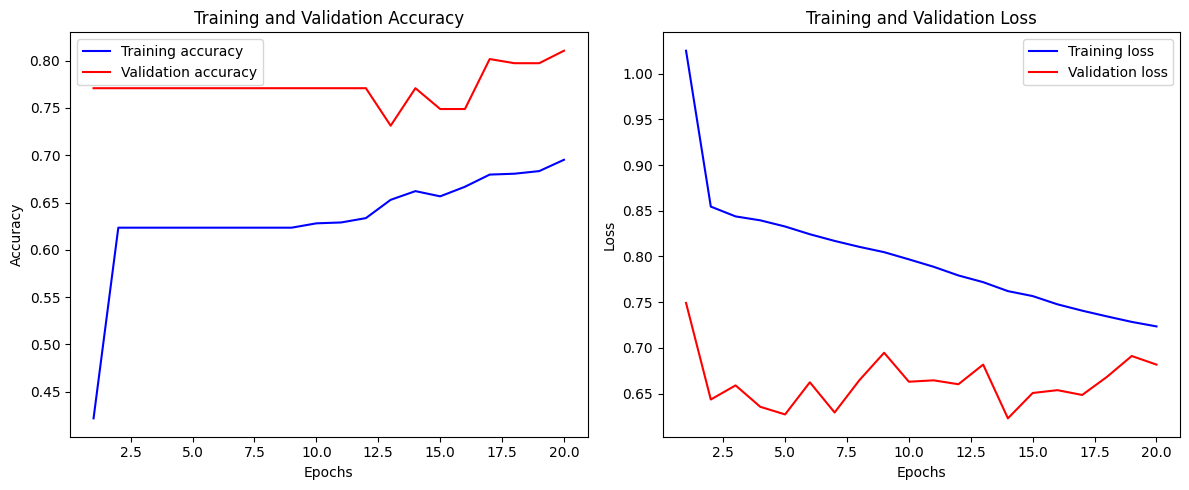

In [39]:
import matplotlib.pyplot as plt

# 獲取訓練記錄數據
history = epochs_metrics_6.history

# 獲取訓練的 epoch 數量
epochs = range(1, len(history['accuracy']) + 1)

## 1. 繪製 Accuracy (準確度) 圖
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1) # 設置第一個子圖
plt.plot(epochs, history['accuracy'], 'b', label='Training accuracy')
plt.plot(epochs, history['val_accuracy'], 'r', label='Validation accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

## 2. 繪製 Loss (損失) 圖
plt.subplot(1, 2, 2) # 設置第二個子圖
plt.plot(epochs, history['loss'], 'b', label='Training loss')
plt.plot(epochs, history['val_loss'], 'r', label='Validation loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout() # 自動調整子圖間距
plt.show()

In [40]:
import numpy as np
import pandas as pd # 確保已引入 pandas
from sklearn.metrics import classification_report, accuracy_score

# 假設 model1 是您訓練好的分類模型
# 假設 X_test_lift 已經準備好
# 假設 df_test_lift 是已經 reset_index(drop=True) 的測試集 DataFrame

# --------------------------------------------------
# 1. 預測：輸出機率分佈 (Softmax output)
# --------------------------------------------------
y_pred_proba = model6.predict(X_test_drive) 

# --------------------------------------------------
# 2. 獲取預測類別：找到機率最大的索引
# --------------------------------------------------
y_pred_classes = np.argmax(y_pred_proba, axis=1) 

# --------------------------------------------------
# 3. 獲取真實標籤：從 df_test_lift 中提取 "揮拍軌跡正確度"
# --------------------------------------------------
# 使用 .values 確保取出的是 NumPy array，並使用 .astype(int) 確保是整數
y_true = df_test_drive['揮拍軌跡正確度'].values.astype(int) 

# 打印整體準確度 (供參考)
test_accuracy = accuracy_score(y_true, y_pred_classes)
print(f"整體測試集準確度 (Overall Test Accuracy): {test_accuracy:.4f}")
print("\n" + "="*50)

# --------------------------------------------------
# 4. 打印分類報告
# --------------------------------------------------
print("詳細類別準確率報告 (Test Classification Report):")
print("-" * 50)
print(classification_report(
    y_true, 
    y_pred_classes, 
    target_names=['0分 (差)', '1分 (普通)', '2分 (好)'],
    digits=4 # 設置輸出精度
))
print("="*50)

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
整體測試集準確度 (Overall Test Accuracy): 0.6515

詳細類別準確率報告 (Test Classification Report):
--------------------------------------------------
              precision    recall  f1-score   support

      0分 (差)     0.0000    0.0000    0.0000        62
     1分 (普通)     0.2381    0.1695    0.1980        59
      2分 (好)     0.7006    0.9018    0.7886       275

    accuracy                         0.6515       396
   macro avg     0.3129    0.3571    0.3289       396
weighted avg     0.5220    0.6515    0.5771       396



c:\Users\gordo\AI-badminton\badminton-venv\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\gordo\AI-badminton\badminton-venv\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\gordo\AI-badminton\badminton-venv\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is",

In [58]:
model7 =  create_model_2(6)
epochs_metrics_7 = model7.fit(X_train_drive[train_indices[1]], y2[train_indices[1]],  validation_data=(X_train_drive[val_indices[1]], y2[val_indices[1]]), batch_size = 16, epochs = 40)

Model: "sequential_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_11 (Conv1D)              │ (None, 116, 16)        │           976 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_11 (MaxPooling1D) │ (None, 38, 16)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_11 (Flatten)            │ (None, 608)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 3)              │         1,827 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,803 (10.95 KB)

 Trainable params: 2,803 (10.95 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/40
67/67 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.4855 - loss: 0.9973 - val_accuracy: 0.2664 - val_loss: 1.0677
Epoch 2/40
67/67 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.4930 - loss: 0.9700 - val_accuracy: 0.2746 - val_loss: 1.0505
Epoch 3/40
67/67 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.4967 - loss: 0.9665 - val_accuracy: 0.2910 - val_loss: 1.0406
Epoch 4/40
67/67 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.5033 - loss: 0.9619 - val_accuracy: 0.2828 - val_loss: 1.0450
Epoch 5/40
67/67 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.5098 - loss: 0.9586 - val_accuracy: 0.2705 - val_loss: 1.0526
Epoch 6/40
67/67 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.5257 - loss: 0.9528 - val_accuracy: 0.2992 - val_loss: 1.0418
Epoch 7/40
67/67 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.5220 - loss: 0.9450 - val_accuracy: 0.2951 - val_loss: 1.0476
Epoch 8/40
67/67 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.5173 - loss: 0.9397 - val_accuracy: 0.2992 - val_loss

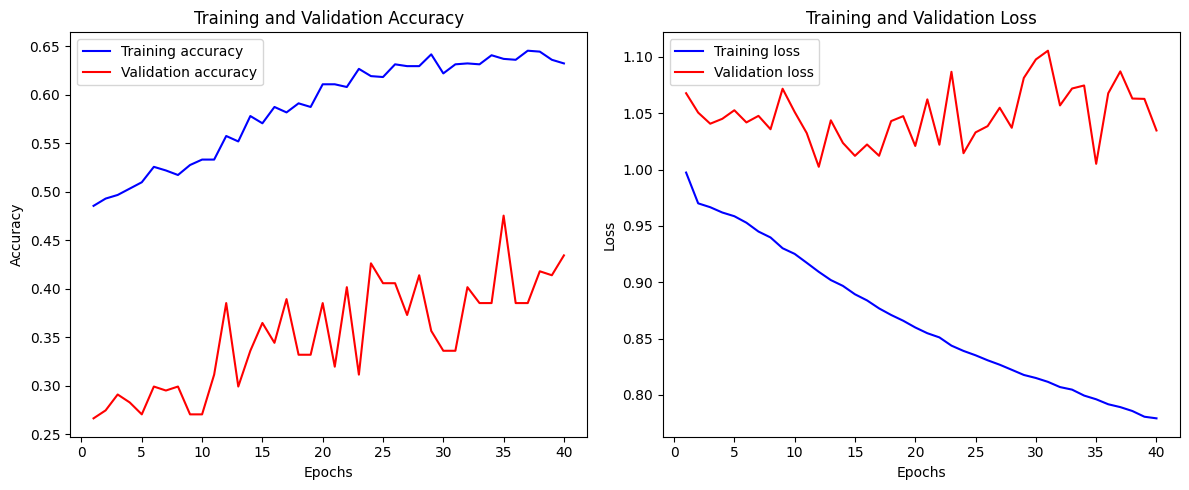

In [59]:
import matplotlib.pyplot as plt

# 獲取訓練記錄數據
history = epochs_metrics_7.history

# 獲取訓練的 epoch 數量
epochs = range(1, len(history['accuracy']) + 1)

## 1. 繪製 Accuracy (準確度) 圖
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1) # 設置第一個子圖
plt.plot(epochs, history['accuracy'], 'b', label='Training accuracy')
plt.plot(epochs, history['val_accuracy'], 'r', label='Validation accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

## 2. 繪製 Loss (損失) 圖
plt.subplot(1, 2, 2) # 設置第二個子圖
plt.plot(epochs, history['loss'], 'b', label='Training loss')
plt.plot(epochs, history['val_loss'], 'r', label='Validation loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout() # 自動調整子圖間距
plt.show()

In [60]:
import numpy as np
import pandas as pd # 確保已引入 pandas
from sklearn.metrics import classification_report, accuracy_score

# 假設 model1 是您訓練好的分類模型
# 假設 X_test_lift 已經準備好
# 假設 df_test_lift 是已經 reset_index(drop=True) 的測試集 DataFrame

# --------------------------------------------------
# 1. 預測：輸出機率分佈 (Softmax output)
# --------------------------------------------------
y_pred_proba = model6.predict(X_test_drive) 

# --------------------------------------------------
# 2. 獲取預測類別：找到機率最大的索引
# --------------------------------------------------
y_pred_classes = np.argmax(y_pred_proba, axis=1) 

# --------------------------------------------------
# 3. 獲取真實標籤：從 df_test_lift 中提取 "揮拍軌跡正確度"
# --------------------------------------------------
# 使用 .values 確保取出的是 NumPy array，並使用 .astype(int) 確保是整數
y_true = df_test_drive['揮拍速度流暢度'].values.astype(int) 

# 打印整體準確度 (供參考)
test_accuracy = accuracy_score(y_true, y_pred_classes)
print(f"整體測試集準確度 (Overall Test Accuracy): {test_accuracy:.4f}")
print("\n" + "="*50)

# --------------------------------------------------
# 4. 打印分類報告
# --------------------------------------------------
print("詳細類別準確率報告 (Test Classification Report):")
print("-" * 50)
print(classification_report(
    y_true, 
    y_pred_classes, 
    target_names=['0分 (差)', '1分 (普通)', '2分 (好)'],
    digits=4 # 設置輸出精度
))
print("="*50)

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
整體測試集準確度 (Overall Test Accuracy): 0.4823

詳細類別準確率報告 (Test Classification Report):
--------------------------------------------------
              precision    recall  f1-score   support

      0分 (差)     0.0000    0.0000    0.0000        62
     1分 (普通)     0.4675    0.8343    0.5992       181
      2分 (好)     0.5479    0.2614    0.3540       153

    accuracy                         0.4823       396
   macro avg     0.3385    0.3652    0.3177       396
weighted avg     0.4254    0.4823    0.4106       396



c:\Users\gordo\AI-badminton\badminton-venv\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\gordo\AI-badminton\badminton-venv\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\gordo\AI-badminton\badminton-venv\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is",

In [80]:
model8 =  create_model_2(6)
epochs_metrics_8 = model8.fit(X_train_drive[train_indices[2]], y3[train_indices[2]],  validation_data=(X_train_drive[val_indices[2]], y3[val_indices[2]]), batch_size = 16, epochs = 7)

Model: "sequential_18"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_18 (Conv1D)              │ (None, 116, 16)        │           976 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_18 (MaxPooling1D) │ (None, 38, 16)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_18 (Flatten)            │ (None, 608)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 3)              │         1,827 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,803 (10.95 KB)

 Trainable params: 2,803 (10.95 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/7
68/68 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.4115 - loss: 1.0846 - val_accuracy: 0.6453 - val_loss: 0.9449
Epoch 2/7
68/68 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.5765 - loss: 0.9604 - val_accuracy: 0.6453 - val_loss: 0.8615
Epoch 3/7
68/68 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.5765 - loss: 0.9340 - val_accuracy: 0.6453 - val_loss: 0.8343
Epoch 4/7
68/68 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.5765 - loss: 0.9268 - val_accuracy: 0.6453 - val_loss: 0.8266
Epoch 5/7
68/68 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.5765 - loss: 0.9203 - val_accuracy: 0.6453 - val_loss: 0.8270
Epoch 6/7
68/68 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.5765 - loss: 0.9151 - val_accuracy: 0.6453 - val_loss: 0.8366
Epoch 7/7
68/68 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.5765 - loss: 0.9056 - val_accuracy: 0.6453 - val_loss: 0.8358


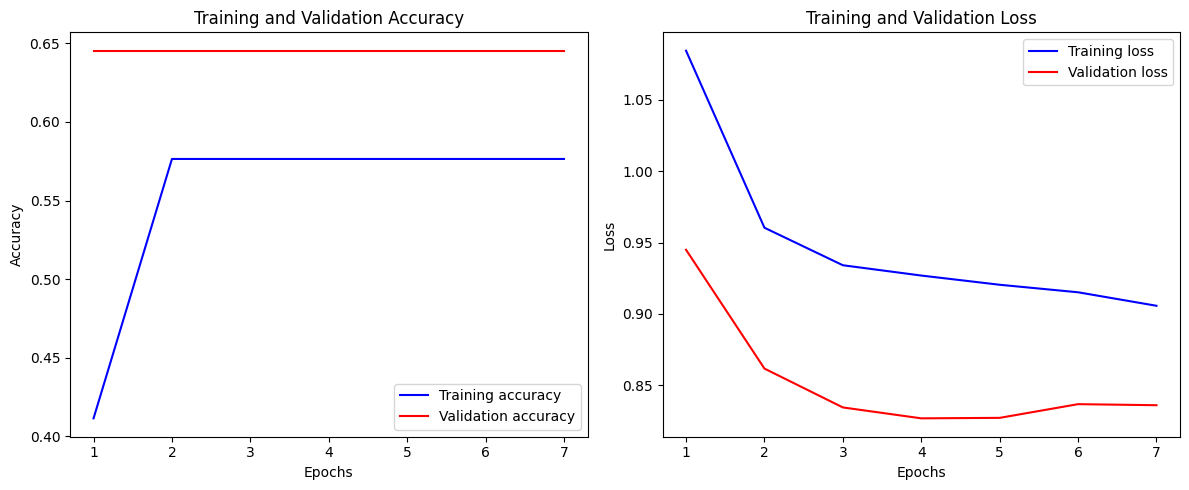

In [82]:
import matplotlib.pyplot as plt

# 獲取訓練記錄數據
history = epochs_metrics_8.history

# 獲取訓練的 epoch 數量
epochs = range(1, len(history['accuracy']) + 1)

## 1. 繪製 Accuracy (準確度) 圖
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1) # 設置第一個子圖
plt.plot(epochs, history['accuracy'], 'b', label='Training accuracy')
plt.plot(epochs, history['val_accuracy'], 'r', label='Validation accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

## 2. 繪製 Loss (損失) 圖
plt.subplot(1, 2, 2) # 設置第二個子圖
plt.plot(epochs, history['loss'], 'b', label='Training loss')
plt.plot(epochs, history['val_loss'], 'r', label='Validation loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout() # 自動調整子圖間距
plt.show()

In [83]:
import numpy as np
import pandas as pd # 確保已引入 pandas
from sklearn.metrics import classification_report, accuracy_score

# 假設 model1 是您訓練好的分類模型
# 假設 X_test_lift 已經準備好
# 假設 df_test_lift 是已經 reset_index(drop=True) 的測試集 DataFrame

# --------------------------------------------------
# 1. 預測：輸出機率分佈 (Softmax output)
# --------------------------------------------------
y_pred_proba = model8.predict(X_test_drive) 

# --------------------------------------------------
# 2. 獲取預測類別：找到機率最大的索引
# --------------------------------------------------
y_pred_classes = np.argmax(y_pred_proba, axis=1) 

# --------------------------------------------------
# 3. 獲取真實標籤：從 df_test_lift 中提取 "揮拍軌跡正確度"
# --------------------------------------------------
# 使用 .values 確保取出的是 NumPy array，並使用 .astype(int) 確保是整數
y_true = df_test_drive['手腕轉動時機正確度'].values.astype(int) 

# 打印整體準確度 (供參考)
test_accuracy = accuracy_score(y_true, y_pred_classes)
print(f"整體測試集準確度 (Overall Test Accuracy): {test_accuracy:.4f}")
print("\n" + "="*50)

# --------------------------------------------------
# 4. 打印分類報告
# --------------------------------------------------
print("詳細類別準確率報告 (Test Classification Report):")
print("-" * 50)
print(classification_report(
    y_true, 
    y_pred_classes, 
    target_names=['0分 (差)', '1分 (普通)', '2分 (好)'],
    digits=4 # 設置輸出精度
))
print("="*50)

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
整體測試集準確度 (Overall Test Accuracy): 0.4621

詳細類別準確率報告 (Test Classification Report):
--------------------------------------------------
              precision    recall  f1-score   support

      0分 (差)     0.0000    0.0000    0.0000        59
     1分 (普通)     0.0000    0.0000    0.0000       154
      2分 (好)     0.4621    1.0000    0.6321       183

    accuracy                         0.4621       396
   macro avg     0.1540    0.3333    0.2107       396
weighted avg     0.2136    0.4621    0.2921       396



c:\Users\gordo\AI-badminton\badminton-venv\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\gordo\AI-badminton\badminton-venv\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\gordo\AI-badminton\badminton-venv\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is",

In [119]:
model9 =  create_model_2(6)
epochs_metrics_9 = model9.fit(X_train_drive[train_indices[3]], y4[train_indices[3]],  validation_data=(X_train_drive[val_indices[3]], y4[val_indices[3]]), batch_size = 16, epochs = 10)

Model: "sequential_30"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_29 (Conv1D)              │ (None, 116, 16)        │           976 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_29 (MaxPooling1D) │ (None, 38, 16)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_29 (Flatten)            │ (None, 608)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_30 (Dense)                │ (None, 3)              │         1,827 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,803 (10.95 KB)

 Trainable params: 2,803 (10.95 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
68/68 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.5256 - loss: 1.0096 - val_accuracy: 0.2500 - val_loss: 1.2088
Epoch 2/10
68/68 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.5256 - loss: 0.9994 - val_accuracy: 0.2500 - val_loss: 1.2037
Epoch 3/10
68/68 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.5256 - loss: 0.9958 - val_accuracy: 0.2500 - val_loss: 1.1917
Epoch 4/10
68/68 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.5256 - loss: 0.9909 - val_accuracy: 0.2500 - val_loss: 1.1727
Epoch 5/10
68/68 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.5256 - loss: 0.9868 - val_accuracy: 0.2500 - val_loss: 1.1910
Epoch 6/10
68/68 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.5256 - loss: 0.9825 - val_accuracy: 0.2500 - val_loss: 1.1718
Epoch 7/10
68/68 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.5256 - loss: 0.9766 - val_accuracy: 0.2500 - val_loss: 1.1568
Epoch 8/10
68/68 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.5266 - loss: 0.9734 - val_accuracy: 0.2500 - val_loss

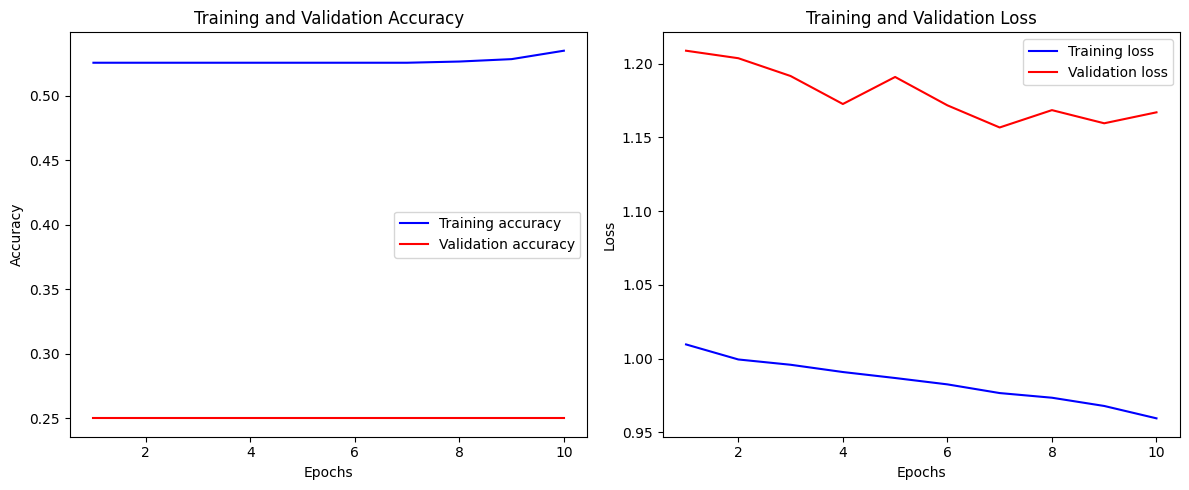

In [120]:
import matplotlib.pyplot as plt

# 獲取訓練記錄數據
history = epochs_metrics_9.history

# 獲取訓練的 epoch 數量
epochs = range(1, len(history['accuracy']) + 1)

## 1. 繪製 Accuracy (準確度) 圖
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1) # 設置第一個子圖
plt.plot(epochs, history['accuracy'], 'b', label='Training accuracy')
plt.plot(epochs, history['val_accuracy'], 'r', label='Validation accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

## 2. 繪製 Loss (損失) 圖
plt.subplot(1, 2, 2) # 設置第二個子圖
plt.plot(epochs, history['loss'], 'b', label='Training loss')
plt.plot(epochs, history['val_loss'], 'r', label='Validation loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout() # 自動調整子圖間距
plt.show()

In [ ]:
import numpy as np
import pandas as pd # 確保已引入 pandas
from sklearn.metrics import classification_report, accuracy_score

# 假設 model1 是您訓練好的分類模型
# 假設 X_test_lift 已經準備好
# 假設 df_test_lift 是已經 reset_index(drop=True) 的測試集 DataFrame

# --------------------------------------------------
# 1. 預測：輸出機率分佈 (Softmax output)
# --------------------------------------------------
y_pred_proba = model9.predict(X_test_drive) 

# --------------------------------------------------
# 2. 獲取預測類別：找到機率最大的索引
# --------------------------------------------------
y_pred_classes = np.argmax(y_pred_proba, axis=1) 

# --------------------------------------------------
# 3. 獲取真實標籤：從 df_test_lift 中提取 "揮拍軌跡正確度"
# --------------------------------------------------
# 使用 .values 確保取出的是 NumPy array，並使用 .astype(int) 確保是整數
y_true = df_test_drive['擊球時機正確度'].values.astype(int) 

# 打印整體準確度 (供參考)
test_accuracy = accuracy_score(y_true, y_pred_classes)
print(f"整體測試集準確度 (Overall Test Accuracy): {test_accuracy:.4f}")
print("\n" + "="*50)

# --------------------------------------------------
# 4. 打印分類報告
# --------------------------------------------------
print("詳細類別準確率報告 (Test Classification Report):")
print("-" * 50)
print(classification_report(
    y_true, 
    y_pred_classes, 
    target_names=['0分 (差)', '1分 (普通)', '2分 (好)'],
    digits=4 # 設置輸出精度
))
print("="*50)

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
整體測試集準確度 (Overall Test Accuracy): 0.4621

詳細類別準確率報告 (Test Classification Report):
--------------------------------------------------
              precision    recall  f1-score   support

          0分     0.0000    0.0000    0.0000        32
          1分     0.0000    0.0000    0.0000       181
          2分     0.4621    1.0000    0.6321       183

    accuracy                         0.4621       396
   macro avg     0.1540    0.3333    0.2107       396
weighted avg     0.2136    0.4621    0.2921       396



c:\Users\gordo\AI-badminton\badminton-venv\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\gordo\AI-badminton\badminton-venv\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\gordo\AI-badminton\badminton-venv\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is",

In [130]:
model10 =  create_model_2(6)
epochs_metrics_10 = model10.fit(X_train_drive[train_indices[4]], y5[train_indices[4]],  validation_data=(X_train_drive[val_indices[4]], y5[val_indices[4]]), batch_size = 16, epochs = 10)

Model: "sequential_33"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_32 (Conv1D)              │ (None, 116, 16)        │           976 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_32 (MaxPooling1D) │ (None, 38, 16)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_32 (Flatten)            │ (None, 608)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_33 (Dense)                │ (None, 3)              │         1,827 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,803 (10.95 KB)

 Trainable params: 2,803 (10.95 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
68/68 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.1996 - loss: 1.2157 - val_accuracy: 0.8398 - val_loss: 0.9216
Epoch 2/10
68/68 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.6285 - loss: 0.8705 - val_accuracy: 0.8442 - val_loss: 0.6359
Epoch 3/10
68/68 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.6285 - loss: 0.7662 - val_accuracy: 0.8442 - val_loss: 0.6177
Epoch 4/10
68/68 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.6285 - loss: 0.7470 - val_accuracy: 0.8442 - val_loss: 0.5831
Epoch 5/10
68/68 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.6285 - loss: 0.7377 - val_accuracy: 0.8442 - val_loss: 0.5725
Epoch 6/10
68/68 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.6285 - loss: 0.7291 - val_accuracy: 0.8442 - val_loss: 0.5623
Epoch 7/10
68/68 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.6285 - loss: 0.7249 - val_accuracy: 0.8268 - val_loss: 0.5970
Epoch 8/10
68/68 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.6285 - loss: 0.7204 - val_accuracy: 0.8398 - val_loss

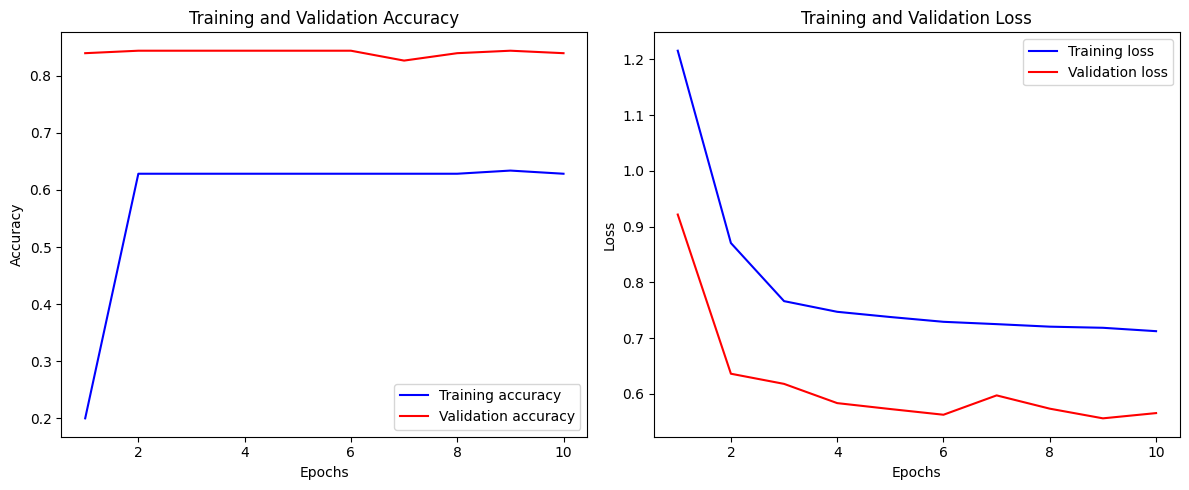

In [131]:
import matplotlib.pyplot as plt

# 獲取訓練記錄數據
history = epochs_metrics_10.history

# 獲取訓練的 epoch 數量
epochs = range(1, len(history['accuracy']) + 1)

## 1. 繪製 Accuracy (準確度) 圖
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1) # 設置第一個子圖
plt.plot(epochs, history['accuracy'], 'b', label='Training accuracy')
plt.plot(epochs, history['val_accuracy'], 'r', label='Validation accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

## 2. 繪製 Loss (損失) 圖
plt.subplot(1, 2, 2) # 設置第二個子圖
plt.plot(epochs, history['loss'], 'b', label='Training loss')
plt.plot(epochs, history['val_loss'], 'r', label='Validation loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout() # 自動調整子圖間距
plt.show()

In [132]:
import numpy as np
import pandas as pd # 確保已引入 pandas
from sklearn.metrics import classification_report, accuracy_score

# 假設 model1 是您訓練好的分類模型
# 假設 X_test_lift 已經準備好
# 假設 df_test_lift 是已經 reset_index(drop=True) 的測試集 DataFrame

# --------------------------------------------------
# 1. 預測：輸出機率分佈 (Softmax output)
# --------------------------------------------------
y_pred_proba = model10.predict(X_test_drive) 

# --------------------------------------------------
# 2. 獲取預測類別：找到機率最大的索引
# --------------------------------------------------
y_pred_classes = np.argmax(y_pred_proba, axis=1) 

# --------------------------------------------------
# 3. 獲取真實標籤：從 df_test_lift 中提取 "揮拍軌跡正確度"
# --------------------------------------------------
# 使用 .values 確保取出的是 NumPy array，並使用 .astype(int) 確保是整數
y_true = df_test_drive['擊球位置正確度'].values.astype(int) 

# 打印整體準確度 (供參考)
test_accuracy = accuracy_score(y_true, y_pred_classes)
print(f"整體測試集準確度 (Overall Test Accuracy): {test_accuracy:.4f}")
print("\n" + "="*50)

# --------------------------------------------------
# 4. 打印分類報告
# --------------------------------------------------
print("詳細類別準確率報告 (Test Classification Report):")
print("-" * 50)
print(classification_report(
    y_true, 
    y_pred_classes, 
    target_names=[f"{l}分" for l in np.unique(y_true)],
    digits=4 # 設置輸出精度
))
print("="*50)

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
整體測試集準確度 (Overall Test Accuracy): 0.6869

詳細類別準確率報告 (Test Classification Report):
--------------------------------------------------
              precision    recall  f1-score   support

          1分     0.0000    0.0000    0.0000       124
          2分     0.6869    1.0000    0.8144       272

    accuracy                         0.6869       396
   macro avg     0.3434    0.5000    0.4072       396
weighted avg     0.4718    0.6869    0.5594       396



c:\Users\gordo\AI-badminton\badminton-venv\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\gordo\AI-badminton\badminton-venv\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\gordo\AI-badminton\badminton-venv\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is",

In [321]:
from tensorflow.keras.models import load_model, Sequential
from tensorflow.keras.layers import Dense

old_model = load_model("models/cnn_base_model1.keras")

cnn_transfer_model1 = Sequential(old_model.layers[:-1])  # 移除最後一層
for layer in cnn_transfer_model1.layers:
    layer.trainable=False
cnn_transfer_model1.add(Dense(3, activation='softmax'))

cnn_transfer_model1.build(input_shape=old_model.input_shape)
cnn_transfer_model1.compile(optimizer=Adam(learning_rate = 0.0001), loss='sparse_categorical_crossentropy', metrics=['accuracy'])
cnn_transfer_model1.summary()

c:\Users\gordo\AI-badminton\badminton-venv\Lib\site-packages\keras\src\saving\saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 10 variables whereas the saved optimizer has 2 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Model: "sequential_70"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_25 (Conv1D)              │ (None, 116, 16)        │           976 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_25 (MaxPooling1D) │ (None, 38, 16)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_15 (Flatten)            │ (None, 608)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_70 (Dense)                │ (None, 3)              │         1,827 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,803 (10.95 KB)

 Trainable params: 1,827 (7.14 KB)

 Non-trainable params: 976 (3.81 KB)

In [322]:
cnn_transfer_epochs_metrics_1 = cnn_transfer_model1.fit(X_train_drive[train_indices[0]], y1[train_indices[0]],  validation_data=(X_train_drive[val_indices[0]], y1[val_indices[0]]), batch_size = 16, epochs = 70)

Epoch 1/70
51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.5301 - loss: 1.0621 - val_accuracy: 0.7987 - val_loss: 0.8706
Epoch 2/70
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6442 - loss: 0.9128 - val_accuracy: 0.7987 - val_loss: 0.7415
Epoch 3/70
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6442 - loss: 0.8421 - val_accuracy: 0.7987 - val_loss: 0.6777
Epoch 4/70
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6442 - loss: 0.8058 - val_accuracy: 0.7987 - val_loss: 0.6469
Epoch 5/70
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6442 - loss: 0.7837 - val_accuracy: 0.7987 - val_loss: 0.6240
Epoch 6/70
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6442 - loss: 0.7700 - val_accuracy: 0.7987 - val_loss: 0.6109
Epoch 7/70
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6442 - loss: 0.7601 - val_accuracy: 0.7987 - val_loss: 0.6019
Epoch 8/70
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6442 - loss: 0.7532 - val_accuracy: 0.7987 - val_loss:

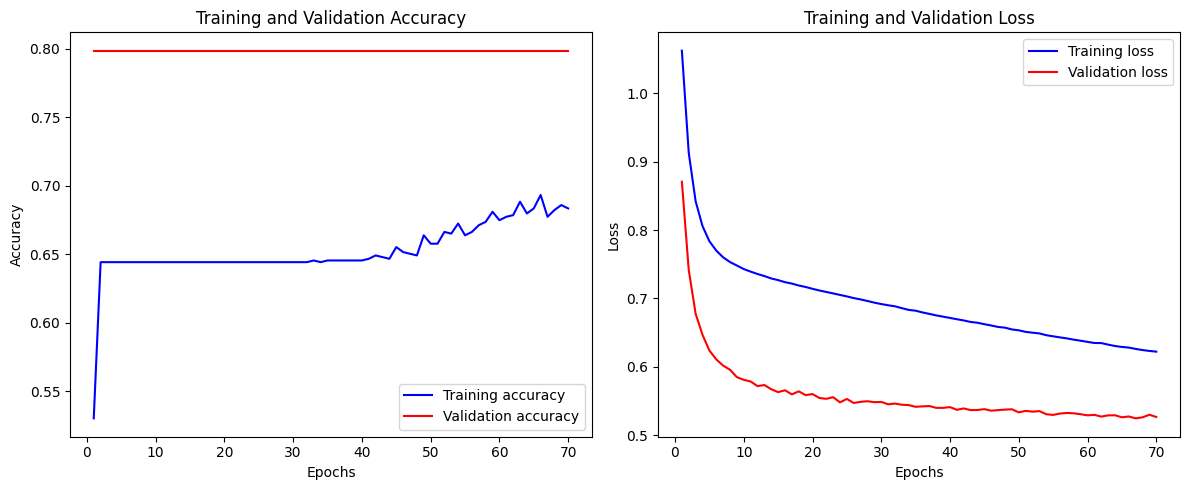

In [325]:
import matplotlib.pyplot as plt

# 獲取訓練記錄數據
history = cnn_transfer_epochs_metrics_1.history

# 獲取訓練的 epoch 數量
epochs = range(1, len(history['accuracy']) + 1)

## 1. 繪製 Accuracy (準確度) 圖
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1) # 設置第一個子圖
plt.plot(epochs, history['accuracy'], 'b', label='Training accuracy')
plt.plot(epochs, history['val_accuracy'], 'r', label='Validation accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

## 2. 繪製 Loss (損失) 圖
plt.subplot(1, 2, 2) # 設置第二個子圖
plt.plot(epochs, history['loss'], 'b', label='Training loss')
plt.plot(epochs, history['val_loss'], 'r', label='Validation loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout() # 自動調整子圖間距
plt.show()

In [326]:
import numpy as np
import pandas as pd # 確保已引入 pandas
from sklearn.metrics import classification_report, accuracy_score

# 假設 model1 是您訓練好的分類模型
# 假設 X_test_lift 已經準備好
# 假設 df_test_lift 是已經 reset_index(drop=True) 的測試集 DataFrame

# --------------------------------------------------
# 1. 預測：輸出機率分佈 (Softmax output)
# --------------------------------------------------
y_pred_proba = cnn_transfer_model1.predict(X_test_drive) 

# --------------------------------------------------
# 2. 獲取預測類別：找到機率最大的索引
# --------------------------------------------------
y_pred_classes = np.argmax(y_pred_proba, axis=1) 

# --------------------------------------------------
# 3. 獲取真實標籤：從 df_test_lift 中提取 "揮拍軌跡正確度"
# --------------------------------------------------
# 使用 .values 確保取出的是 NumPy array，並使用 .astype(int) 確保是整數
y_true = df_test_drive['揮拍軌跡正確度'].values.astype(int) 

# 打印整體準確度 (供參考)
test_accuracy = accuracy_score(y_true, y_pred_classes)
print(f"整體測試集準確度 (Overall Test Accuracy): {test_accuracy:.4f}")
print("\n" + "="*50)

# --------------------------------------------------
# 4. 打印分類報告
# --------------------------------------------------
print("詳細類別準確率報告 (Test Classification Report):")
print("-" * 50)
print(classification_report(
    y_true, 
    y_pred_classes, 
    target_names=['0分 (差)', '1分 (普通)','2分 (好)'],
    digits=4 # 設置輸出精度
))
print("="*50)

24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
整體測試集準確度 (Overall Test Accuracy): 0.6497

詳細類別準確率報告 (Test Classification Report):
--------------------------------------------------
              precision    recall  f1-score   support

      0分 (差)     0.0000    0.0000    0.0000        92
     1分 (普通)     0.1667    0.0261    0.0452       153
      2分 (好)     0.6657    0.9600    0.7862       500

    accuracy                         0.6497       745
   macro avg     0.2775    0.3287    0.2771       745
weighted avg     0.4810    0.6497    0.5370       745



c:\Users\gordo\AI-badminton\badminton-venv\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\gordo\AI-badminton\badminton-venv\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\gordo\AI-badminton\badminton-venv\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is",

In [376]:
from tensorflow.keras.models import load_model, Sequential
from tensorflow.keras.layers import Dense

old_model = load_model("models/cnn_base_model2.keras")

cnn_transfer_model2 = Sequential(old_model.layers[:-1])  # 移除最後一層
for layer in cnn_transfer_model2.layers:
    layer.trainable=False
cnn_transfer_model2.add(Dense(3, activation='softmax'))

cnn_transfer_model2.build(input_shape=old_model.input_shape)
cnn_transfer_model2.compile(optimizer=Adam(learning_rate = 0.0001), loss='sparse_categorical_crossentropy', metrics=['accuracy'])
cnn_transfer_model2.summary()

Model: "sequential_83"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_26 (Conv1D)              │ (None, 116, 16)        │           976 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_26 (MaxPooling1D) │ (None, 38, 16)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_16 (Flatten)            │ (None, 608)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_83 (Dense)                │ (None, 3)              │         1,827 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,803 (10.95 KB)

 Trainable params: 1,827 (7.14 KB)

 Non-trainable params: 976 (3.81 KB)

In [377]:
cnn_transfer_epochs_metrics_2 = cnn_transfer_model2.fit(X_train_drive[train_indices[1]], y2[train_indices[1]],  validation_data=(X_train_drive[val_indices[1]], y2[val_indices[1]]), batch_size = 16, epochs = 10)

Epoch 1/10
51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.3948 - loss: 1.0651 - val_accuracy: 0.5563 - val_loss: 0.9630
Epoch 2/10
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5092 - loss: 0.9242 - val_accuracy: 0.5563 - val_loss: 0.9628
Epoch 3/10
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5277 - loss: 0.9048 - val_accuracy: 0.5497 - val_loss: 0.9713
Epoch 4/10
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5523 - loss: 0.8943 - val_accuracy: 0.5563 - val_loss: 0.9750
Epoch 5/10
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5658 - loss: 0.8836 - val_accuracy: 0.5497 - val_loss: 0.9751
Epoch 6/10
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6015 - loss: 0.8745 - val_accuracy: 0.5563 - val_loss: 0.9770
Epoch 7/10
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5830 - loss: 0.8637 - val_accuracy: 0.5563 - val_loss: 0.9739
Epoch 8/10
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6347 - loss: 0.8543 - val_accuracy: 0.5563 - val_loss:

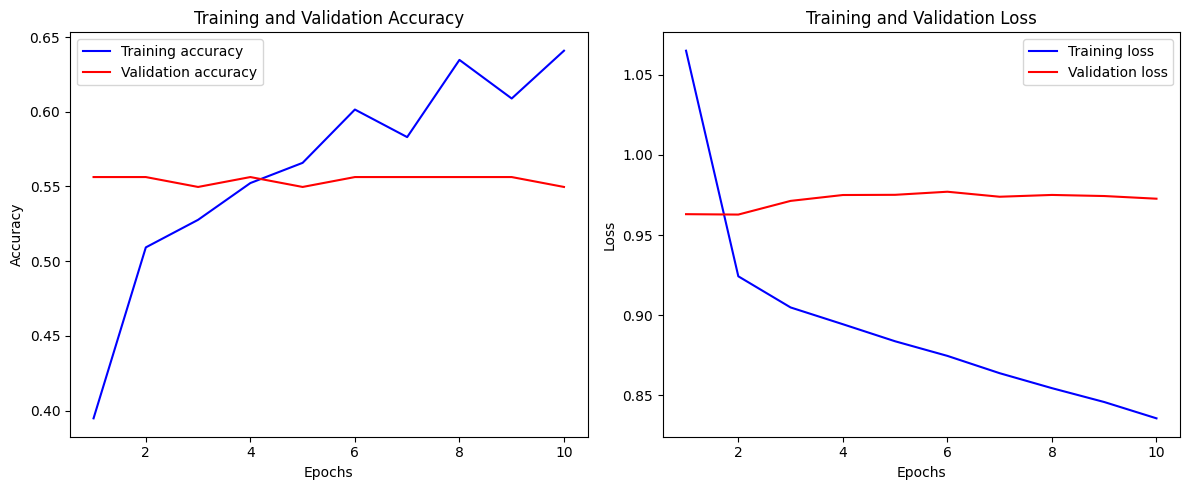

In [378]:
import matplotlib.pyplot as plt

# 獲取訓練記錄數據
history = cnn_transfer_epochs_metrics_2.history

# 獲取訓練的 epoch 數量
epochs = range(1, len(history['accuracy']) + 1)

## 1. 繪製 Accuracy (準確度) 圖
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1) # 設置第一個子圖
plt.plot(epochs, history['accuracy'], 'b', label='Training accuracy')
plt.plot(epochs, history['val_accuracy'], 'r', label='Validation accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

## 2. 繪製 Loss (損失) 圖
plt.subplot(1, 2, 2) # 設置第二個子圖
plt.plot(epochs, history['loss'], 'b', label='Training loss')
plt.plot(epochs, history['val_loss'], 'r', label='Validation loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout() # 自動調整子圖間距
plt.show()

In [379]:
import numpy as np
import pandas as pd # 確保已引入 pandas
from sklearn.metrics import classification_report, accuracy_score

# 假設 model1 是您訓練好的分類模型
# 假設 X_test_lift 已經準備好
# 假設 df_test_lift 是已經 reset_index(drop=True) 的測試集 DataFrame

# --------------------------------------------------
# 1. 預測：輸出機率分佈 (Softmax output)
# --------------------------------------------------
y_pred_proba = cnn_transfer_model1.predict(X_test_drive) 

# --------------------------------------------------
# 2. 獲取預測類別：找到機率最大的索引
# --------------------------------------------------
y_pred_classes = np.argmax(y_pred_proba, axis=1) 

# --------------------------------------------------
# 3. 獲取真實標籤：從 df_test_lift 中提取 "揮拍軌跡正確度"
# --------------------------------------------------
# 使用 .values 確保取出的是 NumPy array，並使用 .astype(int) 確保是整數
y_true = df_test_drive['揮拍速度流暢度'].values.astype(int) 

# 打印整體準確度 (供參考)
test_accuracy = accuracy_score(y_true, y_pred_classes)
print(f"整體測試集準確度 (Overall Test Accuracy): {test_accuracy:.4f}")
print("\n" + "="*50)

# --------------------------------------------------
# 4. 打印分類報告
# --------------------------------------------------
print("詳細類別準確率報告 (Test Classification Report):")
print("-" * 50)
print(classification_report(
    y_true, 
    y_pred_classes, 
    target_names=['0分 (差)', '1分 (普通)','2分 (好)'],
    digits=4 # 設置輸出精度
))
print("="*50)

24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
整體測試集準確度 (Overall Test Accuracy): 0.3879

詳細類別準確率報告 (Test Classification Report):
--------------------------------------------------
              precision    recall  f1-score   support

      0分 (差)     0.0000    0.0000    0.0000        94
     1分 (普通)     0.8750    0.0553    0.1040       380
      2分 (好)     0.3717    0.9889    0.5403       271

    accuracy                         0.3879       745
   macro avg     0.4156    0.3481    0.2148       745
weighted avg     0.5815    0.3879    0.2496       745



c:\Users\gordo\AI-badminton\badminton-venv\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\gordo\AI-badminton\badminton-venv\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\gordo\AI-badminton\badminton-venv\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is",

In [389]:
from tensorflow.keras.models import load_model, Sequential
from tensorflow.keras.layers import Dense

old_model = load_model("models/cnn_base_model3.keras")

cnn_transfer_model3 = Sequential(old_model.layers[:-1])  # 移除最後一層
for layer in cnn_transfer_model3.layers:
    layer.trainable=False
cnn_transfer_model3.add(Dense(3, activation='softmax'))

cnn_transfer_model3.build(input_shape=old_model.input_shape)
cnn_transfer_model3.compile(optimizer=Adam(learning_rate = 0.0001), loss='sparse_categorical_crossentropy', metrics=['accuracy'])
cnn_transfer_model3.summary()

Model: "sequential_87"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_30 (Conv1D)              │ (None, 116, 16)        │           976 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_30 (MaxPooling1D) │ (None, 38, 16)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_20 (Flatten)            │ (None, 608)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_87 (Dense)                │ (None, 3)              │         1,827 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,803 (10.95 KB)

 Trainable params: 1,827 (7.14 KB)

 Non-trainable params: 976 (3.81 KB)

In [390]:
cnn_transfer_epochs_metrics_3 = cnn_transfer_model3.fit(X_train_drive[train_indices[2]], y3[train_indices[2]],  validation_data=(X_train_drive[val_indices[2]], y3[val_indices[2]]), batch_size = 16, epochs = 60)

Epoch 1/60
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6234 - loss: 0.8739 - val_accuracy: 0.2647 - val_loss: 1.4747
Epoch 2/60
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6537 - loss: 0.8349 - val_accuracy: 0.2647 - val_loss: 1.4410
Epoch 3/60
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6537 - loss: 0.8269 - val_accuracy: 0.2647 - val_loss: 1.4088
Epoch 4/60
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6537 - loss: 0.8189 - val_accuracy: 0.2647 - val_loss: 1.4686
Epoch 5/60
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6537 - loss: 0.8137 - val_accuracy: 0.2647 - val_loss: 1.5270
Epoch 6/60
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6537 - loss: 0.8065 - val_accuracy: 0.2647 - val_loss: 1.4928
Epoch 7/60
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6537 - loss: 0.7973 - val_accuracy: 0.2647 - val_loss: 1.5193
Epoch 8/60
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6537 - loss: 0.7906 - val_accuracy: 0.2647 - val_loss:

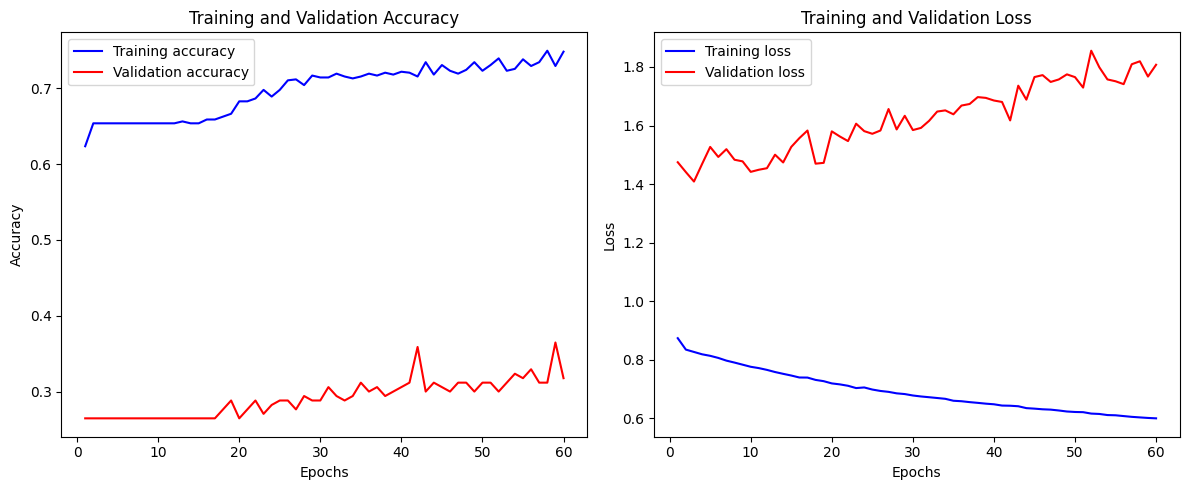

In [392]:
import matplotlib.pyplot as plt

# 獲取訓練記錄數據
history = cnn_transfer_epochs_metrics_3.history

# 獲取訓練的 epoch 數量
epochs = range(1, len(history['accuracy']) + 1)

## 1. 繪製 Accuracy (準確度) 圖
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1) # 設置第一個子圖
plt.plot(epochs, history['accuracy'], 'b', label='Training accuracy')
plt.plot(epochs, history['val_accuracy'], 'r', label='Validation accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

## 2. 繪製 Loss (損失) 圖
plt.subplot(1, 2, 2) # 設置第二個子圖
plt.plot(epochs, history['loss'], 'b', label='Training loss')
plt.plot(epochs, history['val_loss'], 'r', label='Validation loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout() # 自動調整子圖間距
plt.show()

In [393]:
import numpy as np
import pandas as pd # 確保已引入 pandas
from sklearn.metrics import classification_report, accuracy_score

# 假設 model1 是您訓練好的分類模型
# 假設 X_test_lift 已經準備好
# 假設 df_test_lift 是已經 reset_index(drop=True) 的測試集 DataFrame

# --------------------------------------------------
# 1. 預測：輸出機率分佈 (Softmax output)
# --------------------------------------------------
y_pred_proba = cnn_transfer_model3.predict(X_test_drive) 

# --------------------------------------------------
# 2. 獲取預測類別：找到機率最大的索引
# --------------------------------------------------
y_pred_classes = np.argmax(y_pred_proba, axis=1) 

# --------------------------------------------------
# 3. 獲取真實標籤：從 df_test_lift 中提取 "揮拍軌跡正確度"
# --------------------------------------------------
# 使用 .values 確保取出的是 NumPy array，並使用 .astype(int) 確保是整數
y_true = df_test_drive['手腕轉動時機正確度'].values.astype(int) 

# 打印整體準確度 (供參考)
test_accuracy = accuracy_score(y_true, y_pred_classes)
print(f"整體測試集準確度 (Overall Test Accuracy): {test_accuracy:.4f}")
print("\n" + "="*50)

# --------------------------------------------------
# 4. 打印分類報告
# --------------------------------------------------
print("詳細類別準確率報告 (Test Classification Report):")
print("-" * 50)
print(classification_report(
    y_true, 
    y_pred_classes, 
    target_names=['0分 (差)', '1分 (普通)','2分 (好)'],
    digits=4 # 設置輸出精度
))
print("="*50)

24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
整體測試集準確度 (Overall Test Accuracy): 0.4899

詳細類別準確率報告 (Test Classification Report):
--------------------------------------------------
              precision    recall  f1-score   support

      0分 (差)     0.0000    0.0000    0.0000        89
     1分 (普通)     0.5538    0.1208    0.1983       298
      2分 (好)     0.4853    0.9190    0.6351       358

    accuracy                         0.4899       745
   macro avg     0.3464    0.3466    0.2778       745
weighted avg     0.4547    0.4899    0.3845       745



In [418]:
from tensorflow.keras.models import load_model, Sequential
from tensorflow.keras.layers import Dense

old_model = load_model("models/cnn_base_model4.keras")

cnn_transfer_model4 = Sequential(old_model.layers[:-1])  # 移除最後一層
for layer in cnn_transfer_model4.layers:
    layer.trainable=False
cnn_transfer_model4.add(Dense(3, activation='softmax'))

cnn_transfer_model4.build(input_shape=old_model.input_shape)
cnn_transfer_model4.compile(optimizer=Adam(learning_rate = 0.0001), loss='sparse_categorical_crossentropy', metrics=['accuracy'])
cnn_transfer_model4.summary()

Model: "sequential_94"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_34 (Conv1D)              │ (None, 116, 16)        │           976 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_34 (MaxPooling1D) │ (None, 38, 16)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_24 (Flatten)            │ (None, 608)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_94 (Dense)                │ (None, 3)              │         1,827 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,803 (10.95 KB)

 Trainable params: 1,827 (7.14 KB)

 Non-trainable params: 976 (3.81 KB)

In [419]:
cnn_transfer_epochs_metrics_4 = cnn_transfer_model4.fit(X_train_drive[train_indices[3]], y4[train_indices[3]],  validation_data=(X_train_drive[val_indices[3]], y4[val_indices[3]]), batch_size = 16, epochs = 40)

Epoch 1/40
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.4759 - loss: 1.1537 - val_accuracy: 0.5341 - val_loss: 1.1644
Epoch 2/40
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4277 - loss: 0.9834 - val_accuracy: 0.2273 - val_loss: 1.2479
Epoch 3/40
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4340 - loss: 0.9779 - val_accuracy: 0.3352 - val_loss: 1.2230
Epoch 4/40
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4480 - loss: 0.9696 - val_accuracy: 0.3636 - val_loss: 1.2258
Epoch 5/40
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4518 - loss: 0.9627 - val_accuracy: 0.4886 - val_loss: 1.2066
Epoch 6/40
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4772 - loss: 0.9554 - val_accuracy: 0.4545 - val_loss: 1.2486
Epoch 7/40
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4797 - loss: 0.9479 - val_accuracy: 0.3977 - val_loss: 1.2319
Epoch 8/40
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5114 - loss: 0.9422 - val_accuracy: 0.4489 - val_loss:

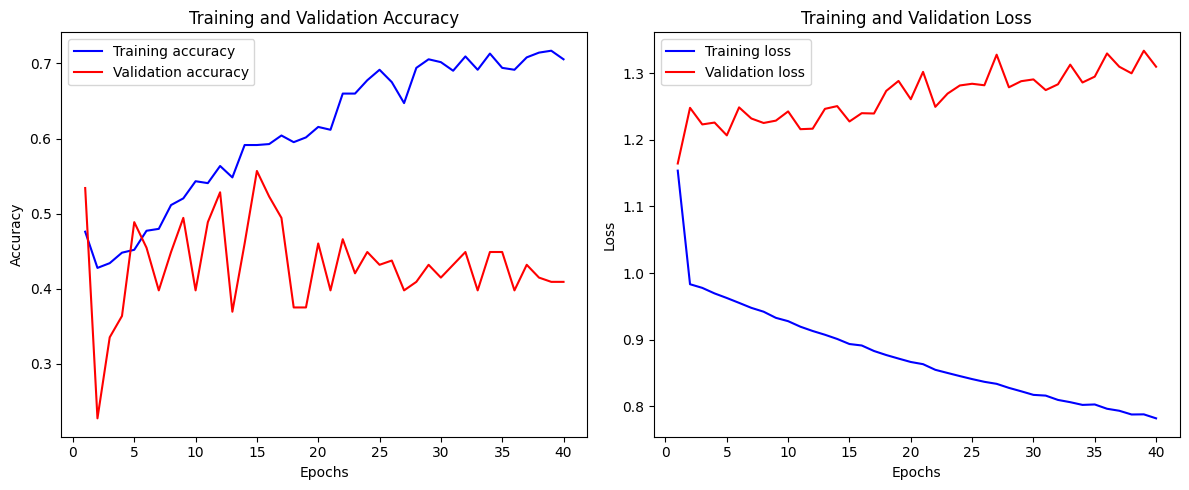

In [420]:
import matplotlib.pyplot as plt

# 獲取訓練記錄數據
history = cnn_transfer_epochs_metrics_4.history

# 獲取訓練的 epoch 數量
epochs = range(1, len(history['accuracy']) + 1)

## 1. 繪製 Accuracy (準確度) 圖
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1) # 設置第一個子圖
plt.plot(epochs, history['accuracy'], 'b', label='Training accuracy')
plt.plot(epochs, history['val_accuracy'], 'r', label='Validation accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

## 2. 繪製 Loss (損失) 圖
plt.subplot(1, 2, 2) # 設置第二個子圖
plt.plot(epochs, history['loss'], 'b', label='Training loss')
plt.plot(epochs, history['val_loss'], 'r', label='Validation loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout() # 自動調整子圖間距
plt.show()

In [421]:
import numpy as np
import pandas as pd # 確保已引入 pandas
from sklearn.metrics import classification_report, accuracy_score

# 假設 model1 是您訓練好的分類模型
# 假設 X_test_lift 已經準備好
# 假設 df_test_lift 是已經 reset_index(drop=True) 的測試集 DataFrame

# --------------------------------------------------
# 1. 預測：輸出機率分佈 (Softmax output)
# --------------------------------------------------
y_pred_proba = cnn_transfer_model4.predict(X_test_drive) 

# --------------------------------------------------
# 2. 獲取預測類別：找到機率最大的索引
# --------------------------------------------------
y_pred_classes = np.argmax(y_pred_proba, axis=1) 

# --------------------------------------------------
# 3. 獲取真實標籤：從 df_test_lift 中提取 "揮拍軌跡正確度"
# --------------------------------------------------
# 使用 .values 確保取出的是 NumPy array，並使用 .astype(int) 確保是整數
y_true = df_test_drive['擊球時機正確度'].values.astype(int) 

# 打印整體準確度 (供參考)
test_accuracy = accuracy_score(y_true, y_pred_classes)
print(f"整體測試集準確度 (Overall Test Accuracy): {test_accuracy:.4f}")
print("\n" + "="*50)

# --------------------------------------------------
# 4. 打印分類報告
# --------------------------------------------------
print("詳細類別準確率報告 (Test Classification Report):")
print("-" * 50)
print(classification_report(
    y_true, 
    y_pred_classes, 
    target_names=['0分 (差)', '1分 (普通)','2分 (好)'],
    digits=4 # 設置輸出精度
))
print("="*50)

24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
整體測試集準確度 (Overall Test Accuracy): 0.4027

詳細類別準確率報告 (Test Classification Report):
--------------------------------------------------
              precision    recall  f1-score   support

      0分 (差)     0.0000    0.0000    0.0000        94
     1分 (普通)     0.4717    0.2857    0.3559       350
      2分 (好)     0.3774    0.6645    0.4813       301

    accuracy                         0.4027       745
   macro avg     0.2830    0.3167    0.2791       745
weighted avg     0.3741    0.4027    0.3617       745



In [434]:
from tensorflow.keras.models import load_model, Sequential
from tensorflow.keras.layers import Dense

old_model = load_model("models/cnn_base_model5.keras")

cnn_transfer_model5 = Sequential(old_model.layers[:-1])  # 移除最後一層
for layer in cnn_transfer_model5.layers:
    layer.trainable=False
cnn_transfer_model5.add(Dense(3, activation='softmax'))

cnn_transfer_model5.build(input_shape=old_model.input_shape)
cnn_transfer_model5.compile(optimizer=Adam(learning_rate = 0.0001), loss='sparse_categorical_crossentropy', metrics=['accuracy'])
cnn_transfer_model5.summary()

Model: "sequential_98"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_35 (Conv1D)              │ (None, 116, 16)        │           976 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_35 (MaxPooling1D) │ (None, 38, 16)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_25 (Flatten)            │ (None, 608)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_98 (Dense)                │ (None, 3)              │         1,827 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,803 (10.95 KB)

 Trainable params: 1,827 (7.14 KB)

 Non-trainable params: 976 (3.81 KB)

In [435]:
cnn_transfer_epochs_metrics_5 = cnn_transfer_model5.fit(X_train_drive[train_indices[4]], y5[train_indices[4]],  validation_data=(X_train_drive[val_indices[4]], y5[val_indices[4]]), batch_size = 16, epochs = 20)

Epoch 1/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.5121 - loss: 0.9425 - val_accuracy: 0.6780 - val_loss: 0.8844
Epoch 2/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7344 - loss: 0.6578 - val_accuracy: 0.6780 - val_loss: 0.9115
Epoch 3/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7344 - loss: 0.6306 - val_accuracy: 0.6780 - val_loss: 0.9478
Epoch 4/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7344 - loss: 0.6212 - val_accuracy: 0.6780 - val_loss: 0.9762
Epoch 5/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7344 - loss: 0.6144 - val_accuracy: 0.6780 - val_loss: 0.9973
Epoch 6/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7344 - loss: 0.6127 - val_accuracy: 0.6780 - val_loss: 1.0182
Epoch 7/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7344 - loss: 0.6050 - val_accuracy: 0.6780 - val_loss: 1.0328
Epoch 8/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7344 - loss: 0.6014 - val_accuracy: 0.6780 - val_loss:

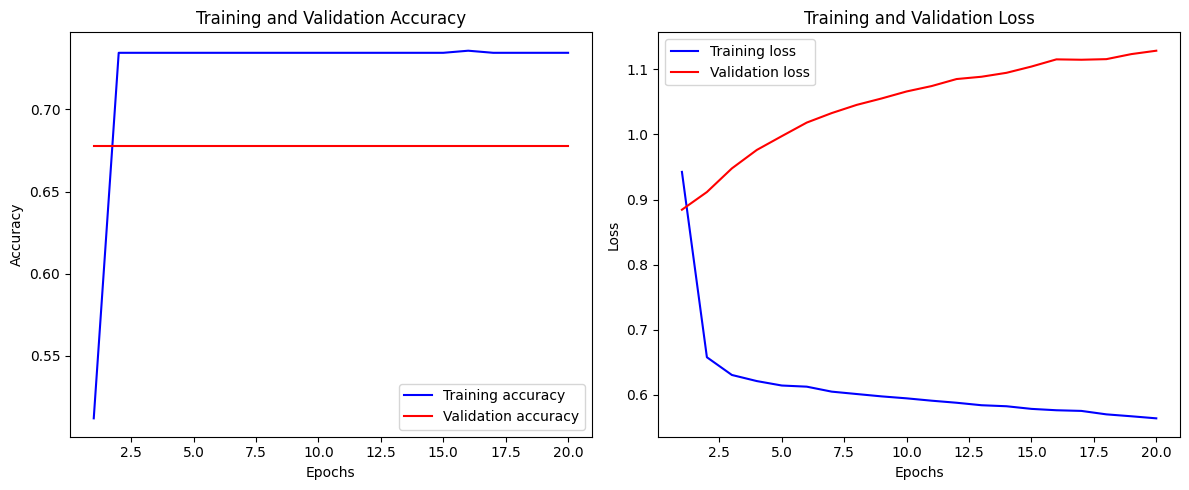

In [436]:
import matplotlib.pyplot as plt

# 獲取訓練記錄數據
history = cnn_transfer_epochs_metrics_5.history

# 獲取訓練的 epoch 數量
epochs = range(1, len(history['accuracy']) + 1)

## 1. 繪製 Accuracy (準確度) 圖
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1) # 設置第一個子圖
plt.plot(epochs, history['accuracy'], 'b', label='Training accuracy')
plt.plot(epochs, history['val_accuracy'], 'r', label='Validation accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

## 2. 繪製 Loss (損失) 圖
plt.subplot(1, 2, 2) # 設置第二個子圖
plt.plot(epochs, history['loss'], 'b', label='Training loss')
plt.plot(epochs, history['val_loss'], 'r', label='Validation loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout() # 自動調整子圖間距
plt.show()

In [437]:
import numpy as np
import pandas as pd # 確保已引入 pandas
from sklearn.metrics import classification_report, accuracy_score

# 假設 model1 是您訓練好的分類模型
# 假設 X_test_lift 已經準備好
# 假設 df_test_lift 是已經 reset_index(drop=True) 的測試集 DataFrame

# --------------------------------------------------
# 1. 預測：輸出機率分佈 (Softmax output)
# --------------------------------------------------
y_pred_proba = cnn_transfer_model5.predict(X_test_drive) 

# --------------------------------------------------
# 2. 獲取預測類別：找到機率最大的索引
# --------------------------------------------------
y_pred_classes = np.argmax(y_pred_proba, axis=1) 

# --------------------------------------------------
# 3. 獲取真實標籤：從 df_test_lift 中提取 "揮拍軌跡正確度"
# --------------------------------------------------
# 使用 .values 確保取出的是 NumPy array，並使用 .astype(int) 確保是整數
y_true = df_test_drive['擊球位置正確度'].values.astype(int) 

# 打印整體準確度 (供參考)
test_accuracy = accuracy_score(y_true, y_pred_classes)
print(f"整體測試集準確度 (Overall Test Accuracy): {test_accuracy:.4f}")
print("\n" + "="*50)

# --------------------------------------------------
# 4. 打印分類報告
# --------------------------------------------------
print("詳細類別準確率報告 (Test Classification Report):")
print("-" * 50)
print(classification_report(
    y_true, 
    y_pred_classes, 
    target_names=[f"{l}分" for l in np.unique(y_true)],
    digits=4 # 設置輸出精度
))
print("="*50)

24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
整體測試集準確度 (Overall Test Accuracy): 0.5866

詳細類別準確率報告 (Test Classification Report):
--------------------------------------------------
              precision    recall  f1-score   support

          1分     0.0000    0.0000    0.0000       308
          2分     0.5866    1.0000    0.7394       437

    accuracy                         0.5866       745
   macro avg     0.2933    0.5000    0.3697       745
weighted avg     0.3441    0.5866    0.4337       745



c:\Users\gordo\AI-badminton\badminton-venv\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\gordo\AI-badminton\badminton-venv\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\gordo\AI-badminton\badminton-venv\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is",